# Single-cell Neighborhood Analysis

Based on the original neighborhood analysis pipeline, the single-cell neighborhood analysis filtered the windows to include only one cell type (paneth in this case).

In [ ]:
!pip install scanpy

In [1]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
import time
import sys
import matplotlib.pyplot as plt
import math
import os
from itertools import product

from sklearn.cluster import MiniBatchKMeans
import seaborn as sns
import scanpy as sc


##### Functions:

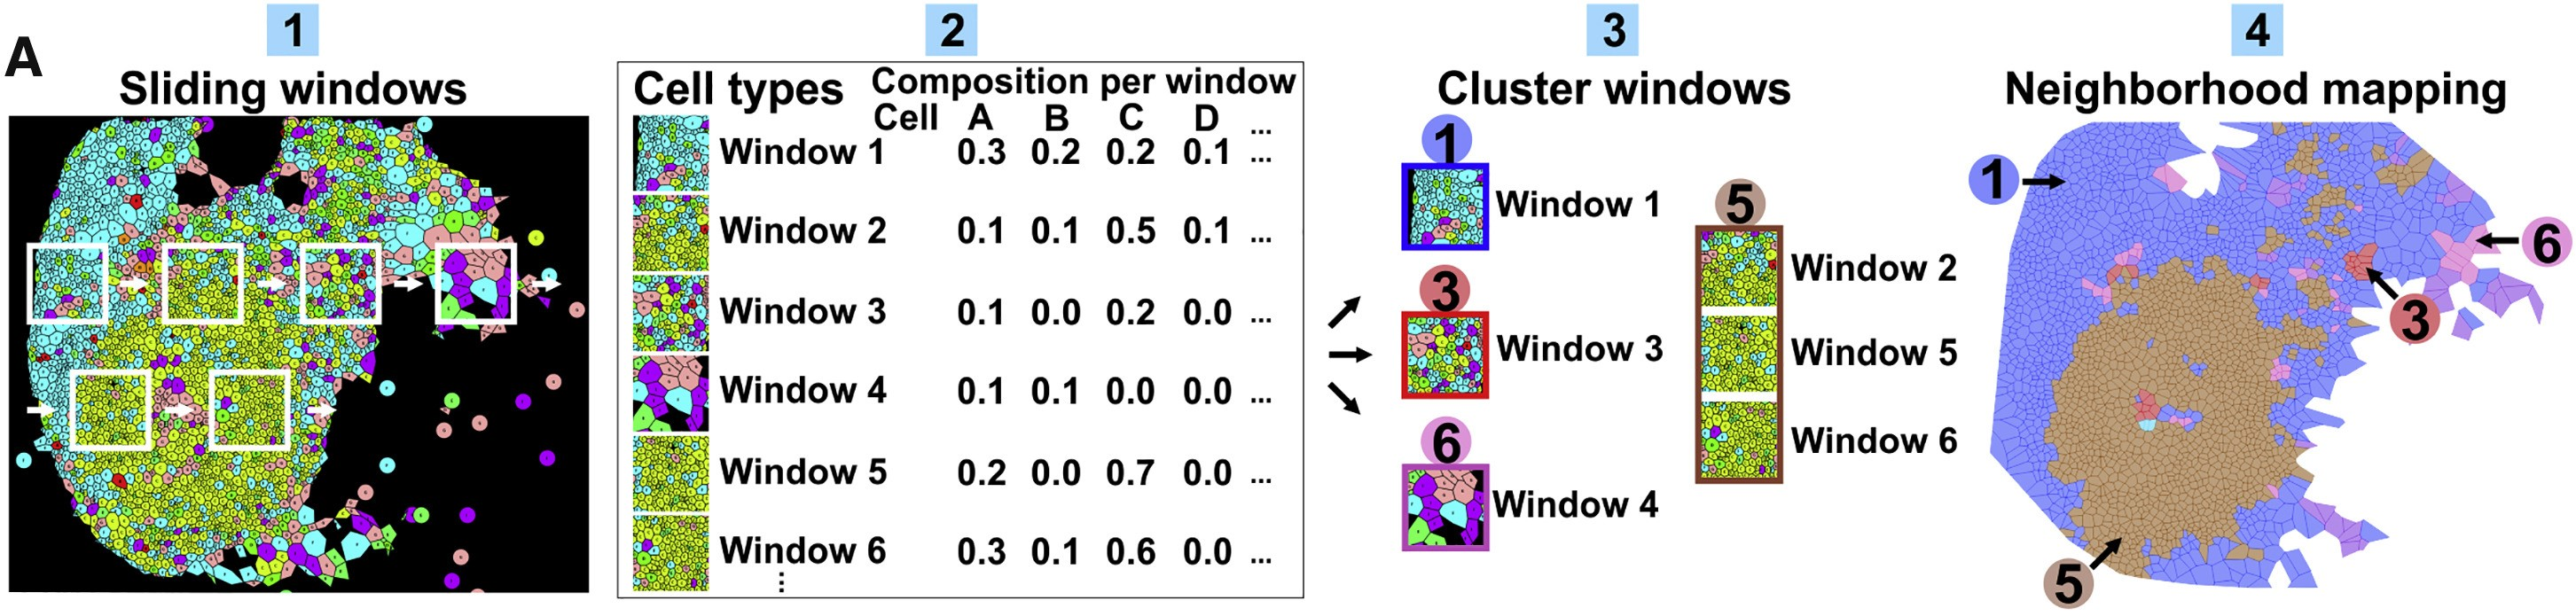

In [2]:
def get_windows(job,n_neighbors):
    start_time,idx,tissue_name,indices = job
    job_start = time.time()

    print ("Starting:", str(idx+1)+'/'+str(len(exps)),': ' + exps[idx])

    tissue = tissue_group.get_group(tissue_name)
    to_fit = tissue.loc[indices][[X,Y]].values

    fit = NearestNeighbors(n_neighbors=n_neighbors).fit(tissue[[X,Y]].values)
    m = fit.kneighbors(to_fit)

    #sort_neighbors
    args = m[0].argsort(axis = 1)
    add = np.arange(m[1].shape[0])*m[1].shape[1]
    sorted_indices = m[1].flatten()[args+add[:,None]]

    neighbors = tissue.index.values[sorted_indices]

    end_time = time.time()

    print ("Finishing:", str(idx+1)+"/"+str(len(exps)),": "+ exps[idx],end_time-job_start,end_time-start_time)
    return neighbors.astype(np.int32)

def get_adata(data, list_keep_obs=None, index_nam = 'tissue_index'):

    if list_keep_obs is None:
        list_keep_obs = ['first_index', 'x', 'y', 'tissue', 'donor', 'region', 'OLFM4', 'FAP',
       'CD25', 'CollIV', 'CK7', 'Xcorr', 'Ycorr', 'unique_region',
       'neigh_name', 'neigh_sub1', 'Preservation_method', 'Tissue_location',
       'array', 'Cell Type', 'Cell Type em', 'Cell subtype', 'machine',
       'MUC6', index_nam]
    data.reset_index(inplace=True)
    data.rename(columns={'index':index_nam}, inplace=True)

    #Prepare for making into anndata format so that obs and data are separate
    data_sc = data.drop(columns = list_keep_obs) #USER INPUT

    #Convert to anndata format
    adata = sc.AnnData(data_sc)
    adata.obs = data[list_keep_obs]
    m_list = adata.var.index.to_list()

    return adata, m_list


def adata_to_dataframe(adata):
    df_var = adata.to_df()
    df_obs = adata.obs
    df = pd.concat([df_var,df_obs], axis=1)
    return df


def sc_heat(data, cell_type, cell_col, vmax=5):
    data_subset = data[data.obs[cell_col] == cell_type]
    sc.pl.heatmap(data_subset, var_names=data.var_names, vmax=vmax, figsize=(20,10), show_gene_labels=True)


def swarm_box(data, grouping, replicate, sub_col, sub_list, per_cat, norm=True,\
              figure_sizing=(10,5), save_name=None, h_order=None):

    plt.style.use(['default'])
    #GENERAL GRAPH SETTINGs
    #font size of graph
    SMALL_SIZE = 14
    MEDIUM_SIZE = 16
    BIGGER_SIZE = 18

    #Settings for graph
    plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
    plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
    plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
    plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
    plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
    plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
    plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

    #Find Percentage of cell type
    test= data.copy()
    sub_list1 = sub_list.copy()

    if norm==True:
        test1 = test.loc[test[sub_col].isin(sub_list1)]
        immune_list = list(test1[per_cat].unique())
    else:
        test1=test.copy()
        immune_list = list(test.loc[test[sub_col].isin(sub_list1)][per_cat].unique())

    test1[per_cat] = test1[per_cat].astype('category')
    test_freq = test1.groupby([grouping,replicate]).apply(lambda x: x[per_cat].value_counts(normalize = True,sort = False)*100)
    test_freq.columns = test_freq.columns.astype(str)
    test_freq.reset_index(inplace=True)
    immune_list.extend([grouping,replicate])
    test_freq1 = test_freq[immune_list]

    melt_per_plot = pd.melt(test_freq1, id_vars=[grouping,replicate,])#,value_vars=immune_list)
    melt_per_plot.rename(columns={'value': 'percentage'}, inplace=True)

    #Order by average
    plot_order = melt_per_plot.groupby(per_cat).mean().reset_index().sort_values(by='percentage')[per_cat].to_list()

    if h_order is None:
        h_order = list(melt_per_plot[grouping].unique())

    #swarmplot to compare clustering
    plt.figure(figsize=figure_sizing)
    ax = sns.boxplot(data = melt_per_plot, x=per_cat,  y='percentage', hue = grouping, dodge=True, order=plot_order,\
                     hue_order=h_order)
    ax = sns.swarmplot(data = melt_per_plot, x=per_cat, y='percentage', hue = grouping, dodge=True, order=plot_order,\
                      hue_order=h_order, edgecolor='black',linewidth=1)
    for patch in ax.artists:
        r, g, b, a = patch.get_facecolor()
        patch.set_facecolor((r, g, b, .3))
    #ax.set_yscale(\log\)
    plt.xlabel('')
    handles, labels = ax.get_legend_handles_labels()
    plt.legend(handles[:len(melt_per_plot[grouping].unique())], labels[:len(melt_per_plot[grouping].unique())],\
               bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.,frameon=False)
    plt.xticks(rotation=90)
    sns.despine(trim=True)
    if save_name:
        plt.savefig(save_path+save_name+'_swarm_boxplot.png', format='png', dpi=300, transparent=True, bbox_inches='tight')

    return melt_per_plot

def stacked_bar_plot(data, per_cat, grouping, cell_list, norm=True, save_name=None,\
              col_order=None, sub_col=None, name_cat = 'Cell Type',fig_sizing=(8,4), pal_color=None):

    #Find Percentage of cell type
    cell_list_1 = cell_list.copy()
    test= data.copy()
    if norm==True:
        if sub_col is None:
            test1 = test.loc[test[per_cat].isin(cell_list_1)]
            sub_cell_list = list(test1[per_cat].unique())
        else:
            test1 = test.loc[test[sub_col].isin(cell_list_1)]
            sub_cell_list = list(test1[per_cat].unique())
    else:
        if sub_col is None:
            test1 = test.copy()
            sub_cell_list = list(test.loc[test[per_cat].isin(cell_list_1)][per_cat].unique())
        else:
            test1 = test.copy()
            sub_cell_list = list(test.loc[test[sub_col].isin(cell_list_1)][per_cat].unique())

    test1[per_cat] = test1[per_cat].astype('category')
    test_freq = test1.groupby(grouping).apply(lambda x: x[per_cat].value_counts(normalize = True,sort = False)*100)
    test_freq.columns = test_freq.columns.astype(str)

    ##### Can subset it here if I do not want normalized per the group
    test_freq.reset_index(inplace=True)
    sub_cell_list.append(grouping)
    test_freq = test_freq[sub_cell_list]
    melt_test = pd.melt(test_freq, id_vars=[grouping])#, value_vars=test_freq.columns)
    melt_test.rename(columns = {per_cat: name_cat, 'value':'percent'},  inplace = True)

    if norm==True:
        if col_order is None:
            bb = melt_test.groupby([grouping, per_cat]).sum().reset_index()
            col_order = bb.loc[bb[per_cat]==bb[per_cat][0]].sort_values(by='percent')[grouping].to_list()
    else:
        if col_order is None:
            col_order = melt_test.groupby(grouping).sum().reset_index().sort_values(by='percent')[grouping].to_list()

    #Set up for plotting
    melt_test_piv = pd.pivot_table(melt_test, columns = [name_cat], index=[grouping], values=['percent'])
    melt_test_piv.columns = melt_test_piv.columns.droplevel(0)
    melt_test_piv.reset_index(inplace=True)
    melt_test_piv.set_index(grouping, inplace=True)
    melt_test_piv = melt_test_piv.reindex(col_order)

    #Get color dictionary
    if pal_color is None:
        cond_list = list(melt_test_piv.columns)
        color_list=list(pal_temp.values())
        pal_color = dict(zip(cond_list, color_list))

    #first subplot
    ax1 = melt_test_piv.plot.bar(alpha = 0.8, linewidth=1, color=[pal_color.get(x) for x in melt_test_piv.columns]\
                                  , figsize =fig_sizing, rot=90,stacked=True, edgecolor='black')
    for line in ax1.lines:
        line.set_color('black')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.set_ylabel('percent')
    #ax1.spines['left'].set_position(('data', 1.0))
    #ax1.set_xticks(np.arange(1,melt_test.day.max()+1,1))
    #ax1.set_ylim([0, int(ceil(max(max(melt_test_piv.sum(axis=1)), max(tm_piv.sum(axis=1)))))])
    plt.xticks(list(range(len(list(melt_test_piv.index)))), list(melt_test_piv.index), rotation=90)
    lgd2 = ax1.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1, frameon=False)
    if save_name:
        plt.savefig(save_path+save_name+'.png', format='png',\
                    dpi=300, transparent=True, bbox_inches='tight')

def area_plot(data, per_cat, grouping, cell_list, sub_col, color_dict=None, \
              norm=False, save_name=None, col_order=None, name_cat = 'Cell Type',fig_sizing=(8,4)):
    if col_order is None:
        col_order=list(data[grouping].unique())

    cell_list_1 = cell_list.copy()
    #Find Percentage of cell type
    test= data.copy()
    if norm==True:
        test1 = test.loc[test[sub_col].isin(cell_list_1)]
        immune_list = list(test1[per_cat].unique())
    else:
        test1 = test.copy()
        immune_list = list(test.loc[test[sub_col].isin(cell_list_1)][per_cat].unique())

    test1[per_cat] = test1[per_cat].astype('category')
    test_freq = test1.groupby(grouping).apply(lambda x: x[per_cat].value_counts(normalize = True,sort = False)*100)
    test_freq.columns = test_freq.columns.astype(str)

    ##### Can subset it here if I do not want normalized per the group
    test_freq.reset_index(inplace=True)
    immune_list.append(grouping)
    test_freq = test_freq[immune_list]
    melt_test = pd.melt(test_freq, id_vars=[grouping])#, value_vars=test_freq.columns)
    melt_test.rename(columns = {per_cat: name_cat, 'value':'percent'},  inplace = True)

    #Set up for plotting
    melt_test_piv = pd.pivot_table(melt_test, columns = [name_cat], index=[grouping], values=['percent'])
    melt_test_piv.columns = melt_test_piv.columns.droplevel(0)
    melt_test_piv.reset_index(inplace=True)
    melt_test_piv.set_index(grouping, inplace=True)
    melt_test_piv = melt_test_piv.reindex(col_order)
    col_order2 = melt_test_piv.mean().sort_values(ascending=False).index.to_list()
    melt_test_piv= melt_test_piv[col_order2]

    #Get color dictionary
    if color_dict is None:
        cond_list = melt_test_piv.columns.to_list()
        color_list=list(pal_temp.values())
        color_dict = dict(zip(cond_list, color_list))

    #first subplot
    ax1 = melt_test_piv.plot.area(alpha = 0.8, linewidth=1, color=[color_dict.get(x) for x in melt_test_piv.columns], figsize =fig_sizing, rot=90)
    for line in ax1.lines:
        line.set_color('black')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.set_ylabel('percent')
    #ax1.spines['left'].set_position(('data', 1.0))
    #ax1.set_xticks(np.arange(1,melt_test.day.max()+1,1))
    #ax1.set_ylim([0, int(ceil(max(max(melt_test_piv.sum(axis=1)), max(tm_piv.sum(axis=1)))))])

    lgd2 = ax1.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1, frameon=False)
    if save_name:
        plt.savefig(save_path+save_name+'_areaplot.png', format='png', dpi=300, transparent=True, bbox_inches='tight')
    #return melt_test_piv

def percent_plot(cells, per, grouping, x_ax, color_col, save_name, transp = True):

    #dataframe of percentages of interest
    cells[per] = cells[per].astype('category')
    neigh_freqs = cells.groupby(grouping).apply(lambda x: x[per].value_counts(normalize = True,sort = False)*100)

    #transpose or not
    if transp==True:
        per_plot = neigh_freqs.T
    else:
        per_plot = neigh_freqs

    #Order by average
    per_plot_ave = (per_plot.mean(axis=1)).to_frame().reset_index()
    per_plot_ave = per_plot_ave.rename(columns = {0:'percent'})
    per_plot_ave = per_plot_ave.sort_values(by = 'percent')
    per_plot_order = per_plot_ave.set_index(x_ax)
    per_plot_order_t = per_plot_order.T
    col_order_list_1 = per_plot_order_t.columns.to_list()

    #melt the data so that can plot on swarmplot
    per_plot.columns = per_plot.columns.astype(str)
    melt_per_plot = pd.melt(per_plot.reset_index(), id_vars=x_ax, value_vars=per_plot.columns[:])
    melt_per_plot.rename(columns={'value': 'percent'}, inplace=True)

    #swarmplot to compare clustering
    plt.figure(figsize=(20, 5))
    ax1 = sns.swarmplot(data = melt_per_plot, x=x_ax, y = 'percent', hue=color_col, order = col_order_list_1, size=8)
    ax1 = sns.pointplot(x_ax, 'percent',data=melt_per_plot, join=False, ci='sd', color='black', errwidth=1, capsize=.2, order = col_order_list_1)
    plt.xlabel('')
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
    plt.xticks(rotation=90)
    plt.savefig(save_path+save_name+'_percent.png', format='png', dpi=300, transparent=True, bbox_inches='tight')
    return melt_per_plot

def catplot2(df, hue, exp='Exp', X='X', Y='Y', invert_y=False, size=3, legend=True, palette="bright", figsize=5, style='white', exps=None, axis='on', scatter_kws={}):
    '''
    Plots cells in a tissue section color-coded by either cell type or node allocation.
    df:  dataframe with cell information
    size:  size of points to plot for each cell.
    hue:  color by "Clusterid" or "Node," respectively.
    legend:  include a legend in the plot.
    '''

    # Define default scatterplot keyword arguments
    scatter_kws_ = {'s': size, 'alpha': 1}
    scatter_kws_.update(scatter_kws)

    figures = []  # A list to store plot figures
    df = df.rename(columns=lambda x: str(x))  # Rename DataFrame columns

    # Ensure the 'hue' column is treated as a categorical variable
    df[hue] = df[hue].astype("category")

    if invert_y:
        # If 'invert_y' is True, invert the Y-values
        y_orig = df[Y].values.copy()
        df[Y] *= -1

    style = {'axes.facecolor': style}
    sns.set_style(style)

    if exps is None:
        exps = list(df[exp].unique())  # Display all experiments if 'exps' is not specified
    elif not isinstance(exps, list):
        exps = [exps]  # Ensure 'exps' is a list

    for name in exps:
        data = df[df[exp] == name]  # Filter data for the specified experiment

        print(name)  # Print the name of the current experiment

        # Create a scatterplot (lmplot) using Seaborn
        f = sns.lmplot(x=X, y=Y, data=data, hue=hue,
                       legend=legend, fit_reg=False, markers='.', height=figsize, palette=palette, scatter=True, scatter_kws=scatter_kws_)

        if axis == 'off':
            # If 'axis' is 'off', remove axis lines and labels
            sns.despine(top=True, right=True, left=True, bottom=True)
            f = f.set(xticks=[], yticks=[]).set_xlabels('').set_ylabels('')

        plt.title(name)  # Set the title of the plot

        plt.show()  # Display the plot
        figures += [f]  # Add the plot figure to the list

    if invert_y:
        df[Y] = y_orig  # Restore the original Y-values if 'invert_y' was used

    return figures


##### Processing code:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# ! git clone https://github.com/HickeyLab/Hierarchical-Tissue-Unit-Annotation.git

In [3]:
#Choose this information and input based on above
ks = [5,10,30,50,100,300] # k=5 means it collects 5 nearest neighbors for each center cell
path_to_data = '/Users/jodie/OneDrive/Documents/Duke/Hickey Lab/23_09_CODEX_HuBMAP_alldata_Dryad_merged.csv'

X = 'x'
Y = 'y'
reg = 'unique_region'
file_type = 'csv'

cellhier_path = '/Users/jodie/OneDrive/Documents/Python Scripts/Hierarchical-Tissue-Unit-Annotation'
sys.path.append(cellhier_path)
from cellhier.general import *
from cellhier.plot_john import *
from cellhier.knn_graph_neighborhood2 import *  # Imports everything

cluster_col = 'Cell Type'
keep_cols = [X,Y,reg,cluster_col]
save_path = '/Users/jodie/OneDrive/Documents/Duke/Hickey Lab/panorgan'

In [4]:
#Import Data

n_neighbors = max(ks)

cells = pd.read_csv(path_to_data)
cells = pd.concat([cells,pd.get_dummies(cells[cluster_col], dtype=int)],axis=1)
sum_cols = cells[cluster_col].unique()
values = cells[sum_cols].values

In [5]:
#Get each region
tissue_group = cells[[X,Y,reg]].groupby(reg)
exps = list(cells[reg].unique())
tissue_chunks = [(time.time(),exps.index(t),t,a) for t,indices in tissue_group.groups.items() for a in np.array_split(indices,1)]
tissues = [get_windows(job,n_neighbors) for job in tissue_chunks]

Starting: 1/66 : B004_Ascending
Finishing: 1/66 : B004_Ascending 1.7429194450378418 1.7429194450378418
Starting: 9/66 : B004_Descending
Finishing: 9/66 : B004_Descending 2.6927764415740967 4.470949172973633
Starting: 51/66 : B004_Descending - Sigmoid
Finishing: 51/66 : B004_Descending - Sigmoid 2.827526092529297 7.404502630233765
Starting: 18/66 : B004_Duodenum
Finishing: 18/66 : B004_Duodenum 3.9250082969665527 11.371202230453491
Starting: 25/66 : B004_Ileum
Finishing: 25/66 : B004_Ileum 2.1422932147979736 13.577486991882324
Starting: 34/66 : B004_Mid-jejunum
Finishing: 34/66 : B004_Mid-jejunum 3.0000717639923096 16.61014986038208
Starting: 42/66 : B004_Proximal Jejunum
Finishing: 42/66 : B004_Proximal Jejunum 2.314955472946167 18.97759246826172
Starting: 59/66 : B004_Transverse
Finishing: 59/66 : B004_Transverse 2.6980271339416504 21.724494695663452
Starting: 2/66 : B005_Ascending
Finishing: 2/66 : B005_Ascending 1.3189070224761963 23.100491285324097
Starting: 10/66 : B005_Descending

In [6]:
#Loop over k to compute neighborhoods
out_dict = {}
for k in ks:
    for neighbors,job in zip(tissues,tissue_chunks):

        chunk = np.arange(len(neighbors))#indices
        tissue_name = job[2]
        indices = job[3]
        window = values[neighbors[chunk,:k].flatten()].reshape(len(chunk),k,len(sum_cols)).sum(axis = 1)
        out_dict[(tissue_name,k)] = (window.astype(np.float16),indices)

windows = {}
for k in ks:

    window = pd.concat([pd.DataFrame(out_dict[(exp,k)][0],index = out_dict[(exp,k)][1].astype(int),columns = sum_cols) for exp in exps],axis=0)
    window = window.loc[cells.index.values]
    window = pd.concat([cells[keep_cols],window],axis=1)
    windows[k] = window

#### Neighborhood Analysis

In [ ]:
#Choose k value to analyze and pull out from dictionary of stored results of vectors
k = 10
windows2 = windows[k]
#Add cell type column to output windows dataframe
windows2[cluster_col] = cells[cluster_col]
windows2

In [ ]:
#Fill in based on above for the number of clusters you want
n_neighborhoods = 15

#return a name of the column for storing the clusters
neighborhood_name = "neighborhood"+str(k) # number of cells per neighborhood


In [ ]:
os.environ['OMP_NUM_THREADS'] = '4' # For running on Windows with MKL

# Initialize a dictionary to store the centroids for each value of 'k'
k_centroids = {}

# Initialize a MiniBatchKMeans clustering model
# 'n_clusters' is set to 'n_neighborhoods', which is the desired number of clusters
# 'random_state=0' ensures reproducibility of the results
km = MiniBatchKMeans(n_clusters=n_neighborhoods, random_state=0)


# Perform clustering on the data in 'windows2' using the columns specified in 'sum_cols'
# '.values' converts the DataFrame to a NumPy array, which is the input format for KMeans
labels = km.fit_predict(windows2[sum_cols].values)

# Store the centroids of the clusters in the 'k_centroids' dictionary, keyed by 'k'
k_centroids[k] = km.cluster_centers_

# Add the cluster labels to the original 'cells' DataFrame
# 'neighborhood_name' is presumably a column name where these labels will be stored
cells[neighborhood_name] = labels


In [ ]:
# Jodie
# number of cells per cluster
cluster_counts = pd.Series(km.labels_).value_counts().sort_index()
cluster_counts

In [ ]:
# Select the centroids for a specific value of 'k' for plotting
k_to_plot = k
niche_clusters = (k_centroids[k_to_plot])

# Calculate the average cell types across the 'values' array
tissue_avgs = values.mean(axis=0)

# Compute fold change (fc) of cell types abundance within a neighborhood versus that in the tissue
# This involves a log2 transformation of the ratio of (niche_clusters + tissue_avgs) to tissue_avgs
# The ratio is normalized by the sum across each row (axis=1), ensuring that the sum of ratios for each row is 1
fc = np.log2(((niche_clusters + tissue_avgs) / (niche_clusters + tissue_avgs).sum(axis=1, keepdims=True)) / tissue_avgs)

# Convert the fold change array into a pandas DataFrame for each cell type
fc = pd.DataFrame(fc, columns=sum_cols)

# Create a clustered heatmap using seaborn's clustermap function
# 'fc' DataFrame is used as input
# vmin and vmax set the color scale limits for the heatmap (-3 to 3 in this case)
# cmap='bwr' sets the color palette to blue-white-red
# figsize=(10,10) sets the size of the heatmap
s = sns.clustermap(fc, vmin=-3, vmax=3, cmap='bwr', figsize=(10,10))


In [ ]:
# Jodie
# Catplot: Highlight a certain cell type while keeping all other cell types in gray
cells['Cell Type Highlight'] = cells['Cell Type'].apply(lambda x: x if x == 'Endothelial' else 'Other')

# Define colors for the cell types
custom_palette = {
    'Endothelial': 'blue',  # Color for endothelial cells
    'Other': 'gray'         # Color for all other cells
}

# Use the updated DataFrame with the `Cell Type Highlight` column
plt.rcParams["legend.markerscale"] = 15
sub_cells = cells.loc[cells['donor']=='B008']
figs = catplot2( sub_cells, X='x', Y='y', exp=reg,
    hue='Cell Type Highlight',  # Updated column to highlight cell type
    invert_y=True, size=2, figsize=8, exps=None, axis='on', scatter_kws={},
    palette=custom_palette  # Use the custom color palette
)

In [ ]:
# Graph Clusters
plt.rcParams["legend.markerscale"] = 15
sub_cells = cells.loc[cells['donor']=='B008']
figs = catplot2(sub_cells, X = 'x', Y='y', exp = 'unique_region',
               hue = neighborhood_name, invert_y=True, size = 2, figsize=8)

In [ ]:
# To plot a subset of neighborhoods
nbhds_to_plot = [4,7]
plt.rcParams["legend.markerscale"] = 15
sub_cells = cells.loc[(cells['donor']=='B008') & (cells[neighborhood_name].isin(nbhds_to_plot))]
figs = catplot2(sub_cells, X = 'x', Y='y', exp = 'unique_region',
               hue = neighborhood_name, invert_y=True, size = 2, figsize=8)


In [ ]:
# Merges clusters by taking the weighted average of their centroids, then removing extra clusters
def combine_clusters(centroids, cluster_groups, cluster_sizes):
    centroids_copy = centroids.copy()
    updated_centroids = []
    removed_clusters = set()

    for group in cluster_groups:
        total_size = sum(cluster_sizes[i] for i in group)
        new_centroid = sum(cluster_sizes[i] * centroids_copy[i] for i in group) / total_size
        updated_centroids.append(new_centroid)
        removed_clusters.update(group)

    for idx in range(len(centroids)):
        if idx not in removed_clusters:
            updated_centroids.append(centroids[idx])
    
    return np.array(updated_centroids)

In [ ]:
test_clusters = np.array([[1,1,1,1], [2,2,2,2], [3,3,3,3], [4,4,4,4], [5,5,5,5]])
cluster_groups = [(3,4), (1,2)]
test_counts = np.array([100, 200, 300, 400, 500])
combine_clusters(test_clusters, cluster_groups, test_counts)

In [ ]:
print(list(merged_nbhds.items()))
print(niche_clusters.shape)

niche_clusters_merged = combine_clusters(niche_clusters.copy(), [(6,8,9),(0,12,13)], cluster_counts)


In [ ]:
# Jodie
# Replot the heatmap with the merged clusters
fc_updated = np.log2(((niche_clusters_merged + tissue_avgs) / (niche_clusters_merged + tissue_avgs).sum(axis=1, keepdims=True)) / tissue_avgs)

# Convert the fold change array into a pandas DataFrame for each cell type
fc_updated = pd.DataFrame(fc_updated, columns=sum_cols)

# Create a clustered heatmap using seaborn's clustermap function
s = sns.clustermap(fc_updated, vmin=-3, vmax=3, cmap='bwr', figsize=(10,10))

In [ ]:
#Use the function to plot the cell neighborhoods back to the tissue coordinates for additional
  #insight to what is

#Just using one donors values for now because of the amount of time to plot all
plt.rcParams["legend.markerscale"] = 15
sub_cells = cells_merged.loc[cells_merged['donor']=='B008']
figs = catplot2(sub_cells, X = 'x', Y='y', exp = 'unique_region',
               hue = neighborhood_name_merged, invert_y=True, size = 2, figsize=8)

#### Single Cell Type Focused

Looking at different nearest number of cells $k$ around endothelial cells and use K means clustering to them as 1 neighborhood. By comparing the composition of each neighborhood with different $k$ values we can see the different tissue structures impacted by distances around endothelial cells.

Cell-type centric neighborhood analysis of endothelial cells. Identify cellls that are co-enriched as neighbors of endothelial cells.

In [7]:
cells[cluster_col].unique()

array(['NK', 'Enterocyte', 'MUC1+ Enterocyte', 'TA', 'CD66+ Enterocyte',
       'Paneth', 'Smooth muscle', 'M1 Macrophage', 'Goblet',
       'Neuroendocrine', 'CD57+ Enterocyte', 'Lymphatic', 'CD8+ T', 'DC',
       'M2 Macrophage', 'B', 'Neutrophil', 'Endothelial', 'Cycling TA',
       'Plasma', 'CD4+ T cell', 'Stroma', 'Nerve', 'ICC', 'CD7+ Immune'],
      dtype=object)

In [8]:
os.environ['OMP_NUM_THREADS'] = '4' # For running on Windows with MKL

#Fill in based on above
k = 50
n_neighborhoods = 20
neighborhood_name = "neighborhood"+str(k)
k_centroids = {}

#choose windows with k calculated of interest
cluster_col1 = 'Neighborhood' # 'Neighborhood' for community analysis, 'Cell Type' for neighborhood analysis
windows2 = windows[k]
windows2[cluster_col1] = cells[cluster_col1]

#Only use T cell windows for example in cell_list
cell_name = 'endothelial cells'
#cell_list = ['Paneth','OLFM4+ Enterocyte']
cell_list = ['Endothelial']
cluster_col = 'Cell Type'
celltype_windows = windows2[windows2[cluster_col].isin(cell_list)]
type_cells = cells[cells[cluster_col].isin(cell_list)]

#Add labels
km = MiniBatchKMeans(n_clusters = n_neighborhoods,random_state=0)

labels = km.fit_predict(celltype_windows[sum_cols].values)
k_centroids[k] = km.cluster_centers_
type_cells[neighborhood_name] = labels

#Get out heat
k_to_plot = k
niche_clusters = (k_centroids[k_to_plot])
tissue_avgs = values.mean(axis = 0)
fc = np.log2(((niche_clusters+tissue_avgs)/(niche_clusters+tissue_avgs).sum(axis = 1, keepdims = True))/tissue_avgs)
fc = pd.DataFrame(fc,columns = sum_cols)
fc_output = fc.rename(index={0:k})

# type_cells.to_csv('type_cells.csv', index=False)

c:\Users\jodie\anaconda3\envs\nbhd_analysis\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\jodie\AppData\Local\Temp\ipykernel_16224\290203233.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  type_cells[neighborhood_name] = labels


B008_Right


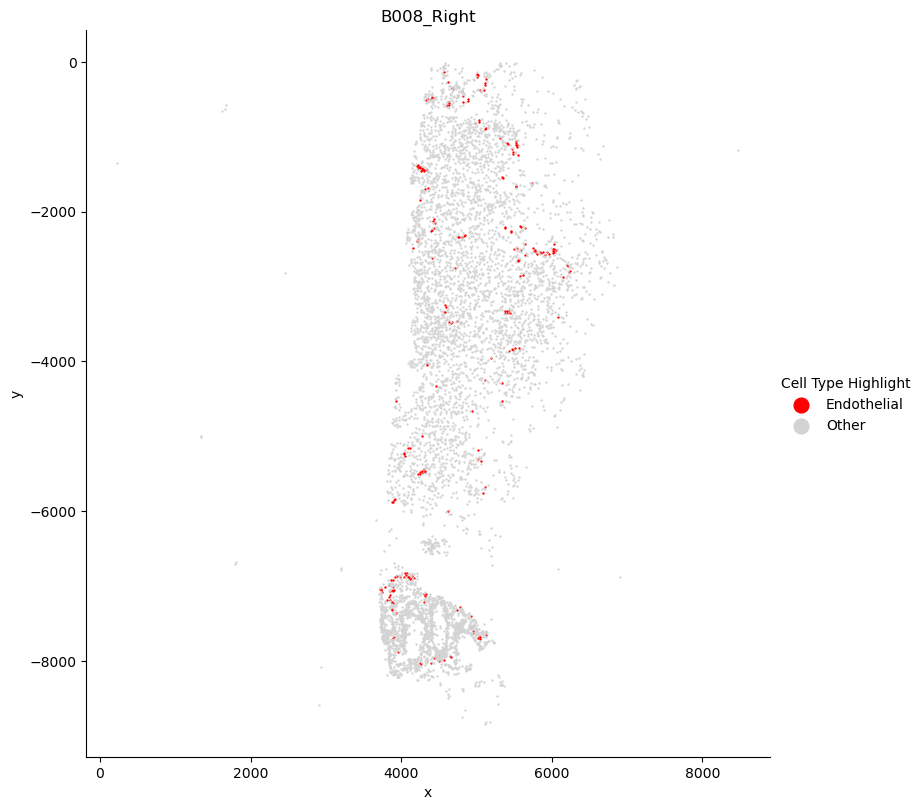

B008_Left


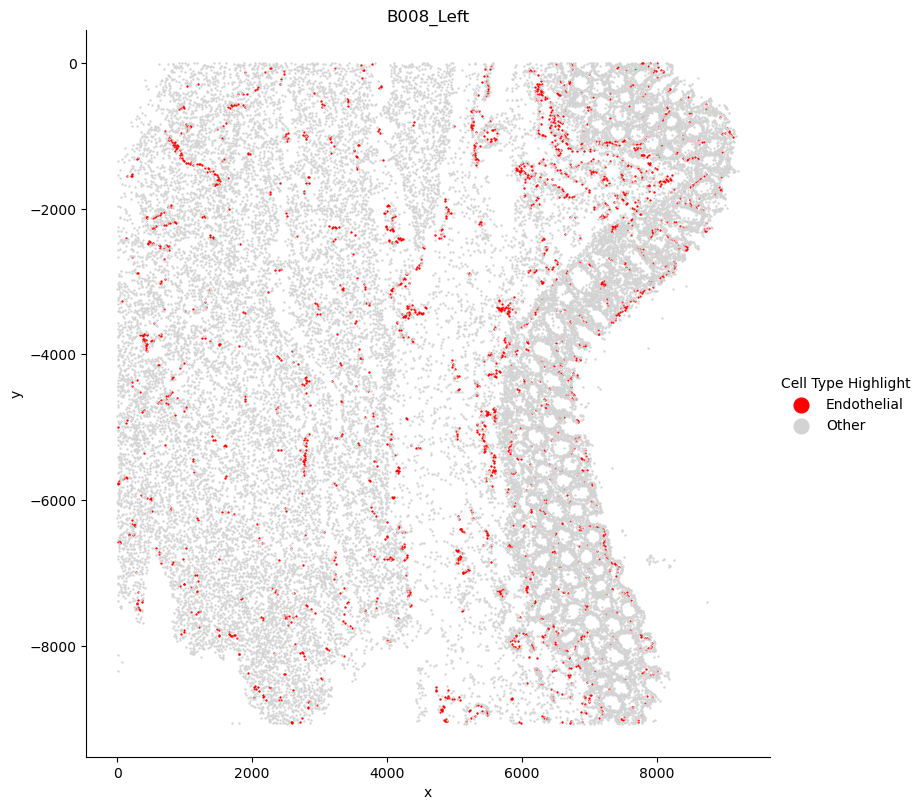

B008_Duodenum


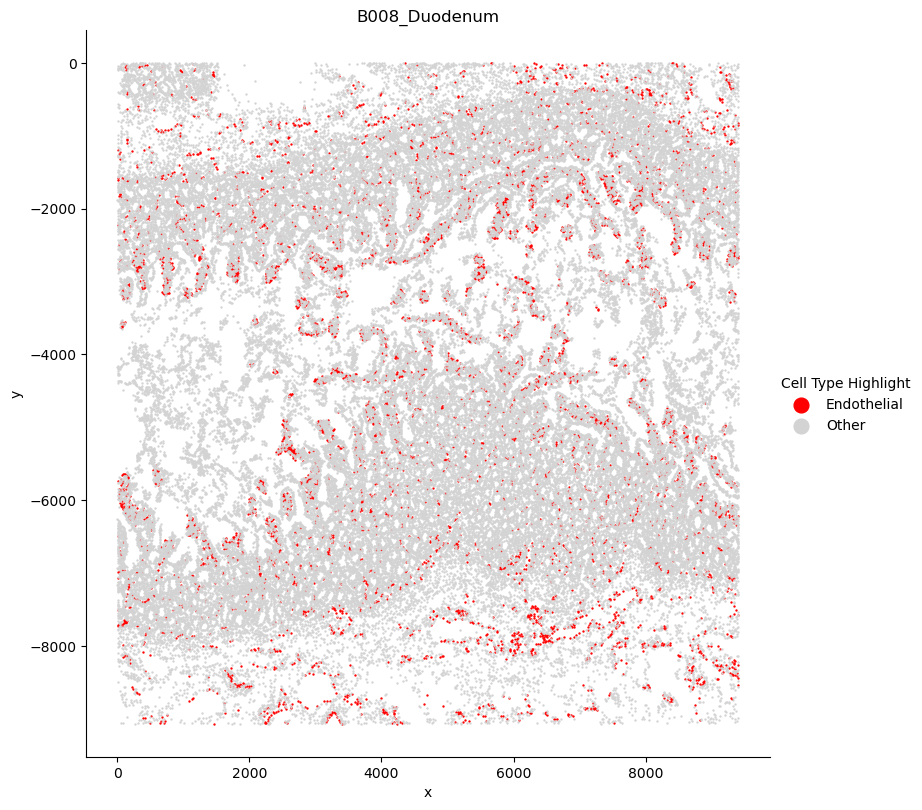

B008_Ileum


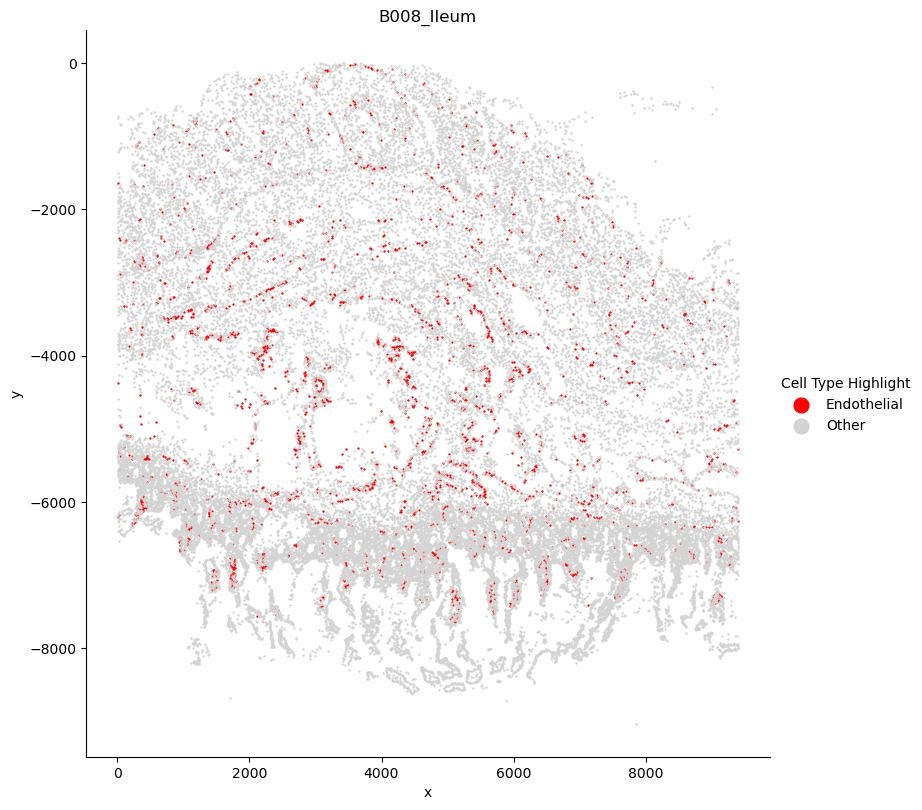

B008_Mid jejunum


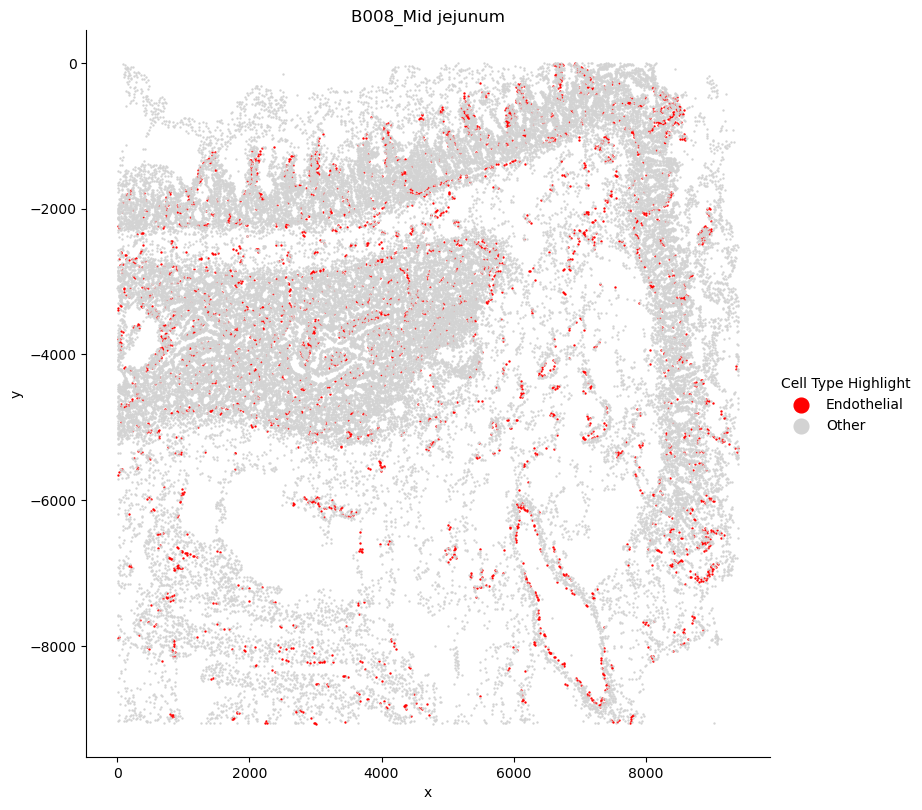

B008_Proximal jejunum


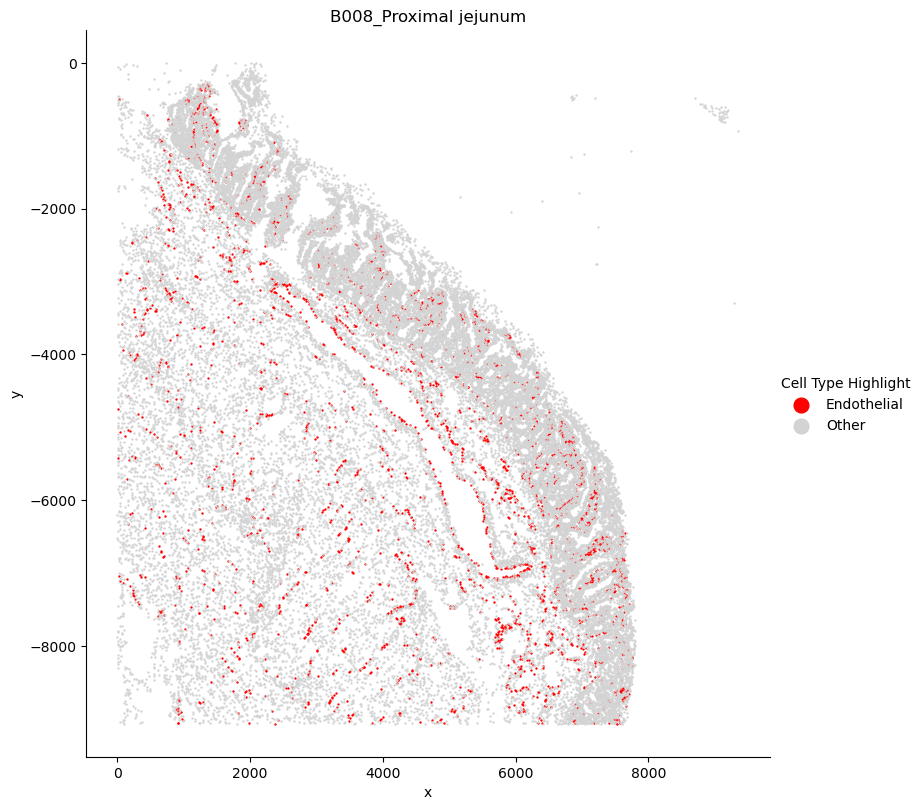

B008_Proximal jejunum_extra


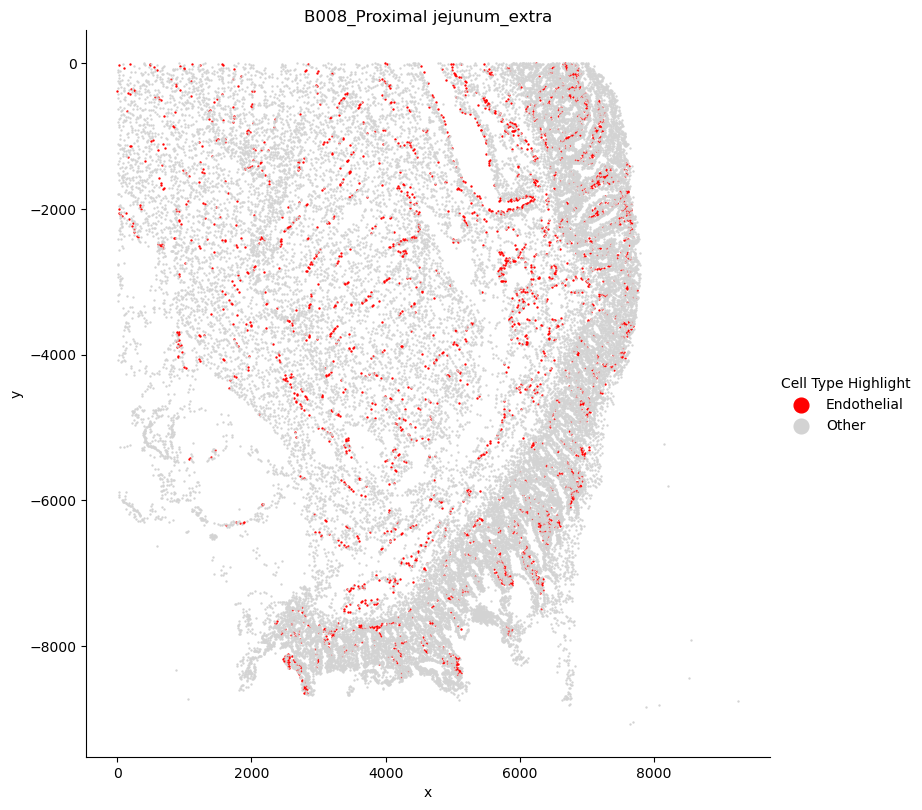

B008_Sigmoid


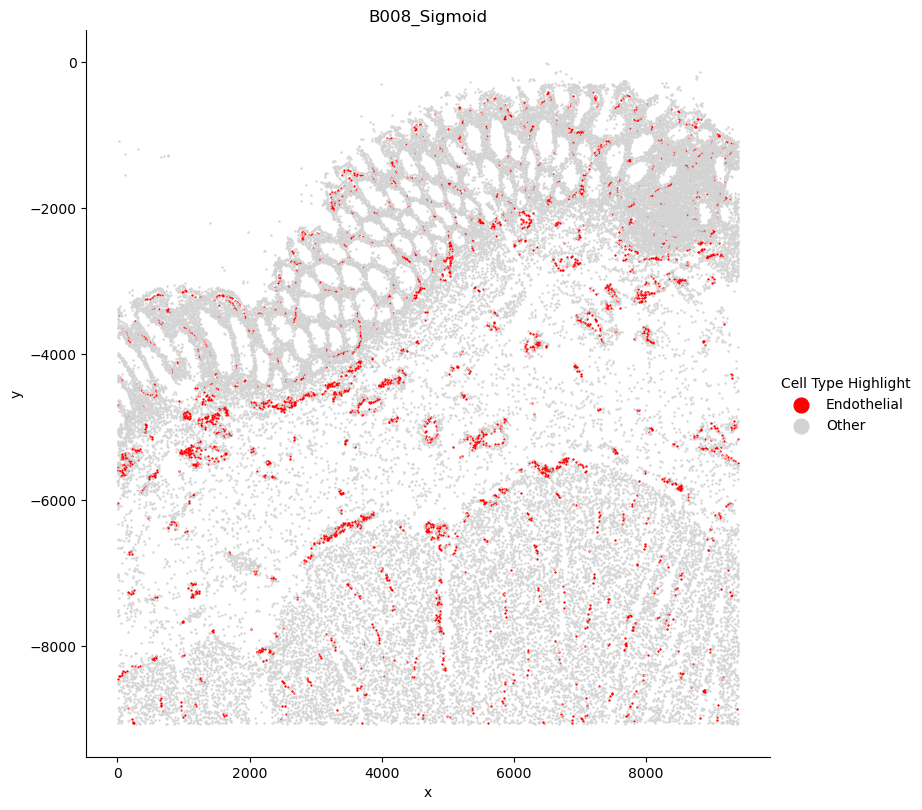

B008_Trans


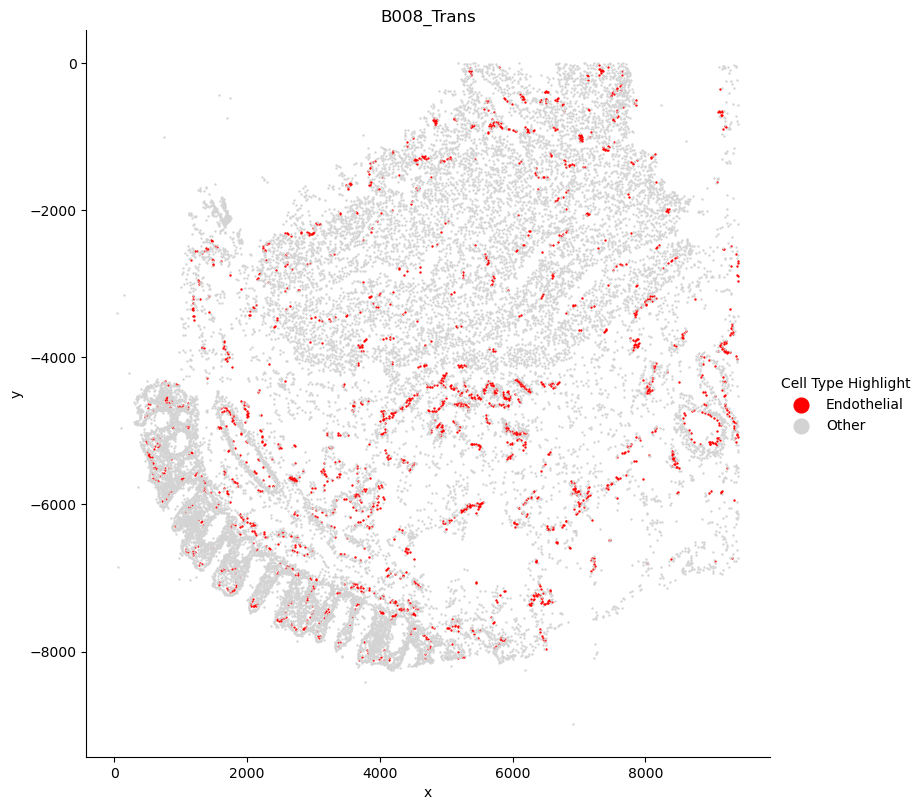

In [9]:
# Jodie
# Catplot highlighting endothelial cells
cells['Cell Type Highlight'] = cells['Cell Type'].apply(lambda x: x if x == 'Endothelial' else 'Other')

# Define colors for the cell types
custom_palette = {
    'Endothelial': 'red',  # Color for endothelial cells
    'Other': 'lightgray'         # Color for all other cells
}

# Use the updated DataFrame with the `Cell Type Highlight` column
plt.rcParams["legend.markerscale"] = 15
sub_cells = cells.loc[cells['donor']=='B008']
figs = catplot2(sub_cells, X='x', Y='y', exp=reg, hue='Cell Type Highlight',  # Updated column to highlight endothelial cells
    invert_y=True, size=2, figsize=8, exps=None, axis='on',scatter_kws={},palette=custom_palette  # Use the custom color palette
)

In [ ]:
# Jodie
# Number of cells per cluster
cluster_counts = pd.Series(km.labels_).value_counts().sort_index()

In [ ]:
#modify figure size aesthetics for each neighborhood
plt.rcParams["legend.markerscale"] = 3
sub_cells = type_cells.loc[type_cells['donor']=='B008']
figs = catplot2(sub_cells,X = 'x',Y='y', exp= reg,
               hue = 'Cell Type',invert_y=False,size = 1,figsize=8, exps=None, axis='on', scatter_kws={})

Index(['M1 Macrophage', 'NK', 'DC', 'CD4+ T cell', 'Endothelial', 'Neutrophil',
       'Lymphatic', 'M2 Macrophage', 'ICC', 'Stroma', 'Smooth muscle', 'Nerve',
       'B', 'MUC1+ Enterocyte', 'CD57+ Enterocyte', 'Paneth', 'Neuroendocrine',
       'Cycling TA', 'TA', 'Goblet', 'Enterocyte', 'CD66+ Enterocyte',
       'Plasma', 'CD8+ T', 'CD7+ Immune'],
      dtype='object')


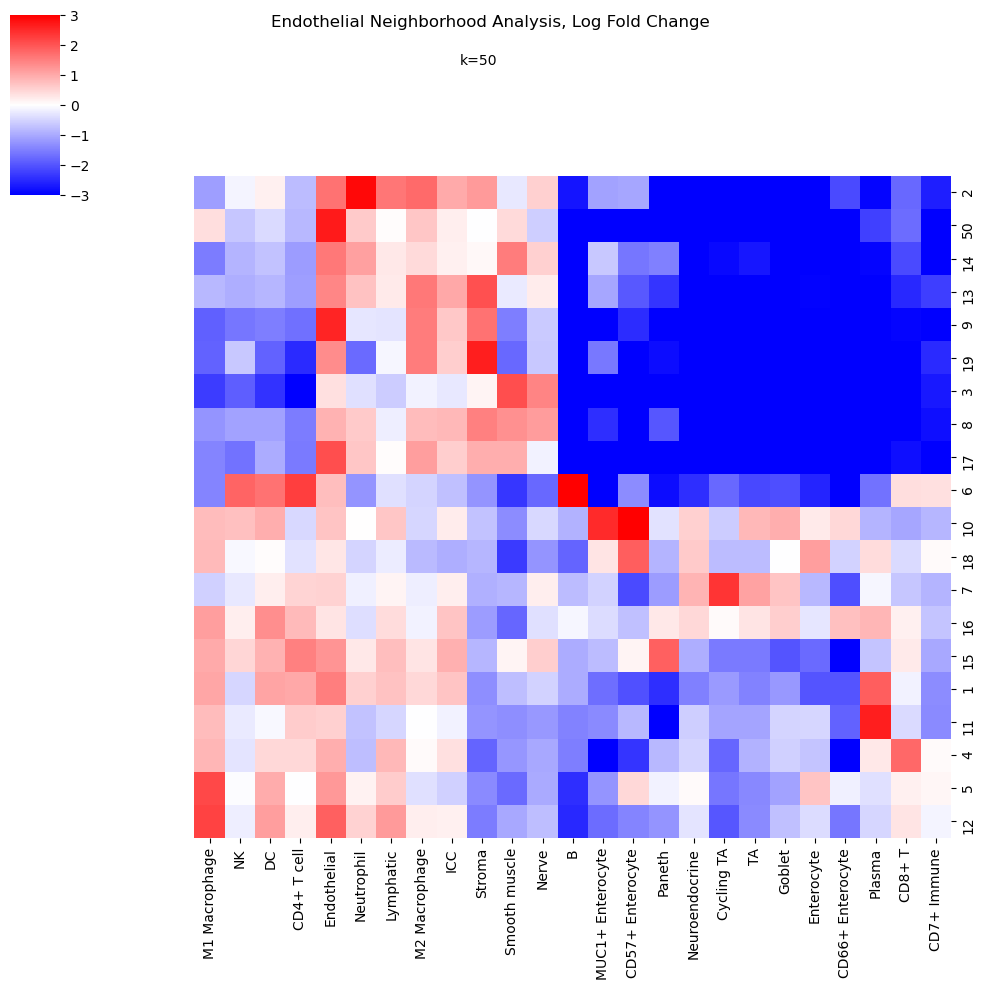

In [10]:
#this plot shows the types of cells (ClusterIDs) in the different niches (0-9)
# k_to_plot = k
# niche_clusters = (k_centroids[k_to_plot])
# tissue_avgs = values.mean(axis = 0)
# fc = np.log2(((niche_clusters+tissue_avgs)/(niche_clusters+tissue_avgs).sum(axis = 1, keepdims = True))/tissue_avgs)
# fc = pd.DataFrame(fc,columns = sum_cols)
# fixed_order = fc_output[''].to_list()

s=sns.clustermap(fc_output, vmin =-3,vmax = 3,cmap = 'bwr', figsize=(10,10)) #col_cluster = fixed_order
s.ax_row_dendrogram.set_visible(False)  # Hide the row dendrogram
s.ax_col_dendrogram.set_visible(False) 
y_axis_order = s.dendrogram_row.reordered_ind
x_axis_order = s.dendrogram_col.reordered_ind
x_axis_labels = fc_output.columns[x_axis_order]
s.fig.suptitle('Endothelial Neighborhood Analysis, Log Fold Change')
titlename = 'k='+str(k)
s.fig.text(x=0.47, y=0.93, s = titlename )
print(x_axis_labels)

In [ ]:
# To plot a subset of the clustermap
fc_output1 = fc_output.copy().iloc[[2,3,7],:]
s = sns.clustermap(fc_output1, vmin=-3, vmax=3, cmap='bwr', figsize=(10, 5))

In [ ]:
# To plot specific neighborhoods
nbhds_to_plot = [2,3,7]
plt.rcParams["legend.markerscale"] = 15
sub_cells = type_cells.loc[(type_cells['donor']=='B011') & (type_cells[neighborhood_name].isin(nbhds_to_plot))]
figs = catplot2(sub_cells, X = 'x', Y='y', exp = 'unique_region',
               hue = neighborhood_name, invert_y=True, size = 2, figsize=8)

In [11]:
# Jodie
# Merge Clusters
# Cluster annotations based on k=50 and n=20

neighborhood_name_merged = neighborhood_name + '_merged'
merged_nbhds = {0:'Endothelial Rich',
                1:'Plasma Cell Enriched',
                2:'Stroma + Innate Immune',
                3:'Innervated Smooth Muscle',
                4:'Immune Enriched',
                5:'Immune Enriched',
                6:'Follicle',
                7:'Cycling TA',
                8:'Smooth Muscle + Innate Immune',
                9:'Stroma',
                10:'Glandular Epithelial',
                11:'Plasma Cell Enriched',
                12:'Immune Enriched',
                13:'Stroma',
                14:'Smooth Muscle + Innate Immune',
                15:'Paneth + Immune',
                16:'Cycling TA',
                17:'Smooth Muscle + Innate Immune',
                18:'Glandular Epithelial',
                19:'Stroma',
                }
type_cells_merged = type_cells.copy()
type_cells_merged[neighborhood_name_merged] = type_cells_merged[neighborhood_name].replace(merged_nbhds)
# type_cells_merged.to_csv('type_cells_merged.csv', index=False)
type_cells_merged

,Unnamed: 0,MUC2,SOX9,MUC1,CD31,Synapto,CD49f,CD15,CHGA,CDX2,...,Nerve,Neuroendocrine,Neutrophil,Paneth,Plasma,Smooth muscle,Stroma,TA,neighborhood50,neighborhood50_merged
45963,45963,-0.282975,-0.067833,-0.404255,7.453614,-0.108976,1.543719,-0.298396,-0.121452,0.217616,...,0,0,0,0,0,0,0,0,1,Plasma Cell Enriched
45964,45964,-0.303918,-0.401183,-0.418962,2.513711,-0.086206,0.047894,-0.299031,-0.117950,-0.110319,...,0,0,0,0,0,0,0,0,1,Plasma Cell Enriched
45965,45965,-0.300649,-0.263042,-0.508927,9.420748,-0.161263,2.083842,-0.299027,-0.121458,0.111092,...,0,0,0,0,0,0,0,0,1,Plasma Cell Enriched
45966,45966,-0.304219,-0.586728,-0.443083,3.332058,-0.222937,0.861612,-0.299030,-0.121456,-0.326023,...,0,0,0,0,0,0,0,0,1,Plasma Cell Enriched
45967,45967,-0.304217,-0.196822,-0.357673,4.692658,-0.179436,0.903561,0.008151,-0.115496,0.021169,...,0,0,0,0,0,0,0,0,1,Plasma Cell Enriched
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2595523,2595523,0.545075,-0.230780,-0.265767,2.589661,-0.128645,0.330391,-0.255556,-0.077780,-0.152068,...,0,0,0,0,0,0,0,0,17,Smooth Muscle + Innate Immune
2595524,2595524,-0.070891,0.060327,-0.392731,1.251389,-0.220205,0.025961,-0.349517,-0.107311,-0.182427,...,0,0,0,0,0,0,0,0,14,Smooth Muscle + Innate Immune
2595525,2595525,-0.170110,0.841373,-0.290619,7.075575,-0.057473,0.595641,-0.302567,-0.103299,-0.039416,...,0,0,0,0,0,0,0,0,14,Smooth Muscle + Innate Immune
2595526,2595526,0.103511,-0.066546,-0.301168,4.982898,-0.118907,0.478768,-0.311979,-0.103500,-0.064307,...,0,0,0,0,0,0,0,0,14,Smooth Muscle + Innate Immune


B008_Right


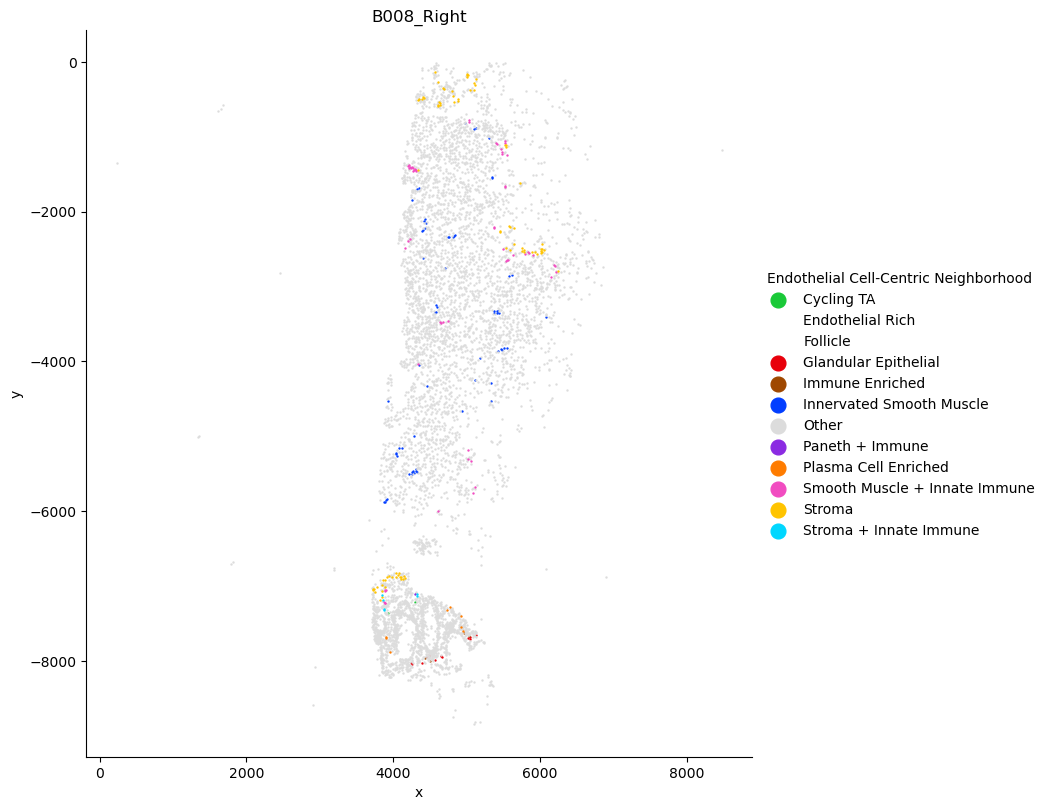

B008_Left


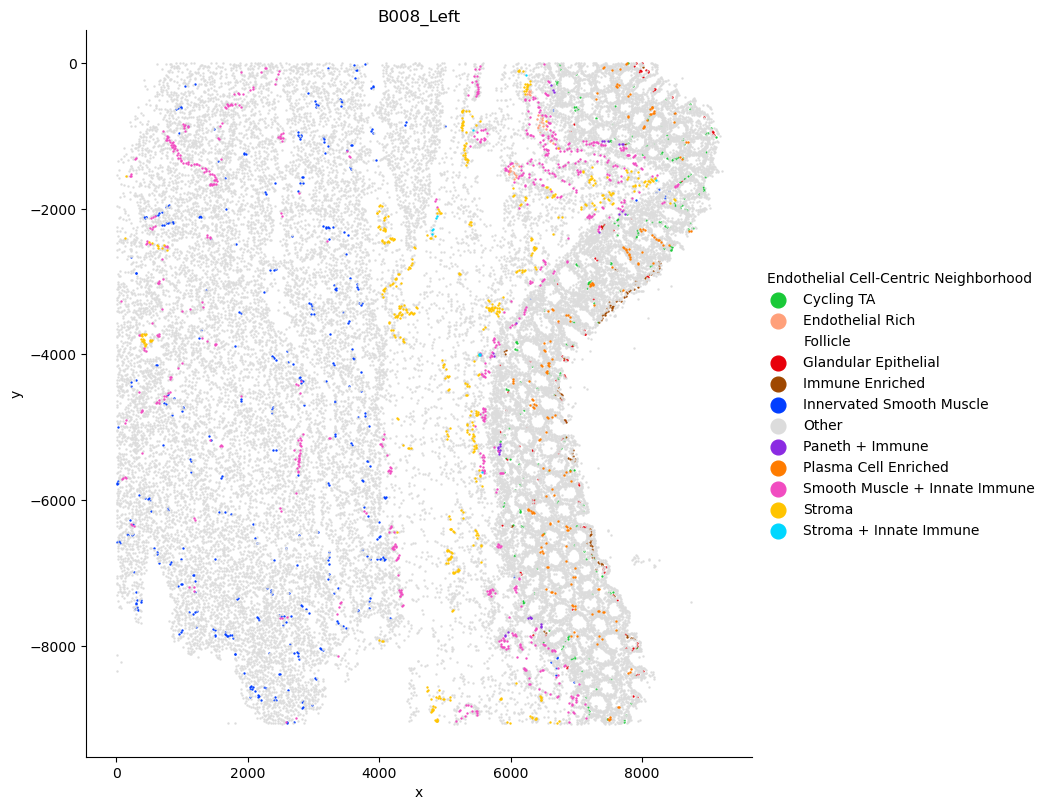

B008_Duodenum


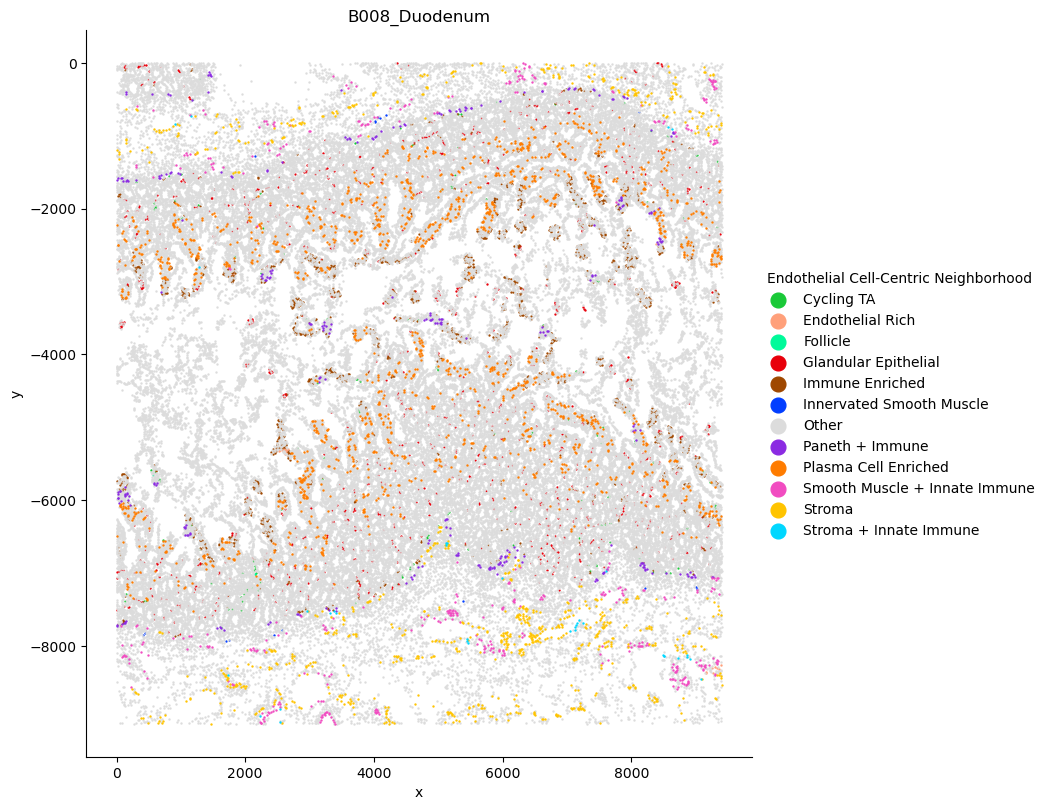

B008_Ileum


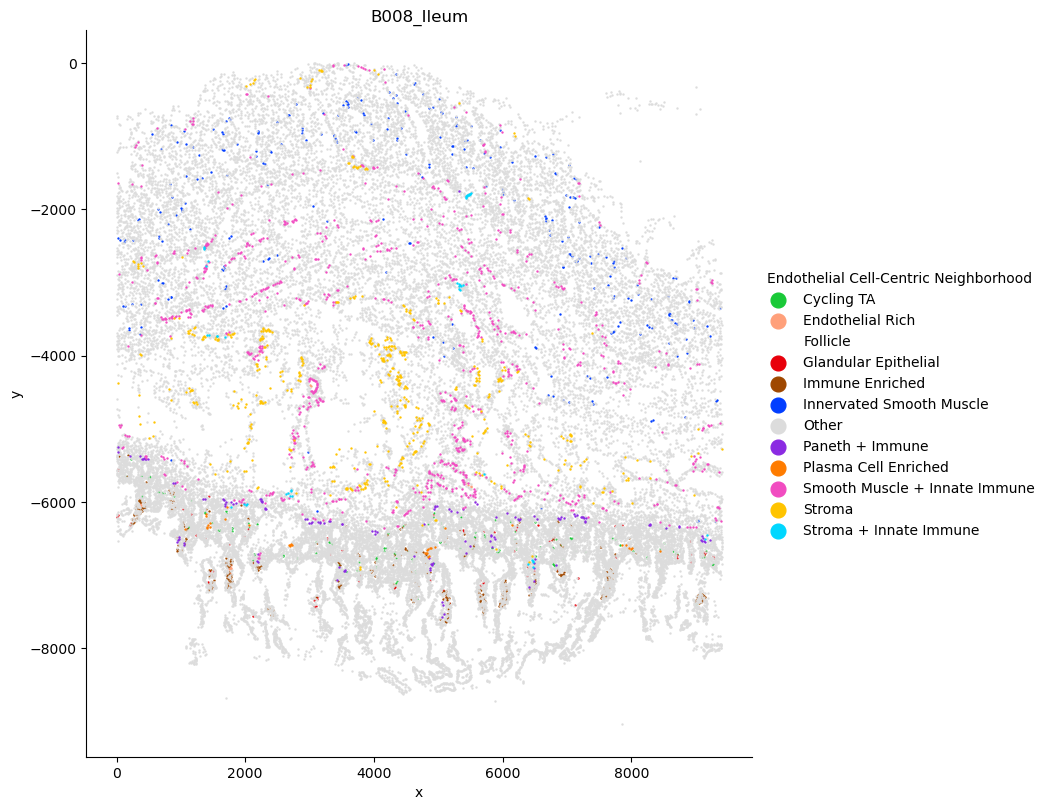

B008_Mid jejunum


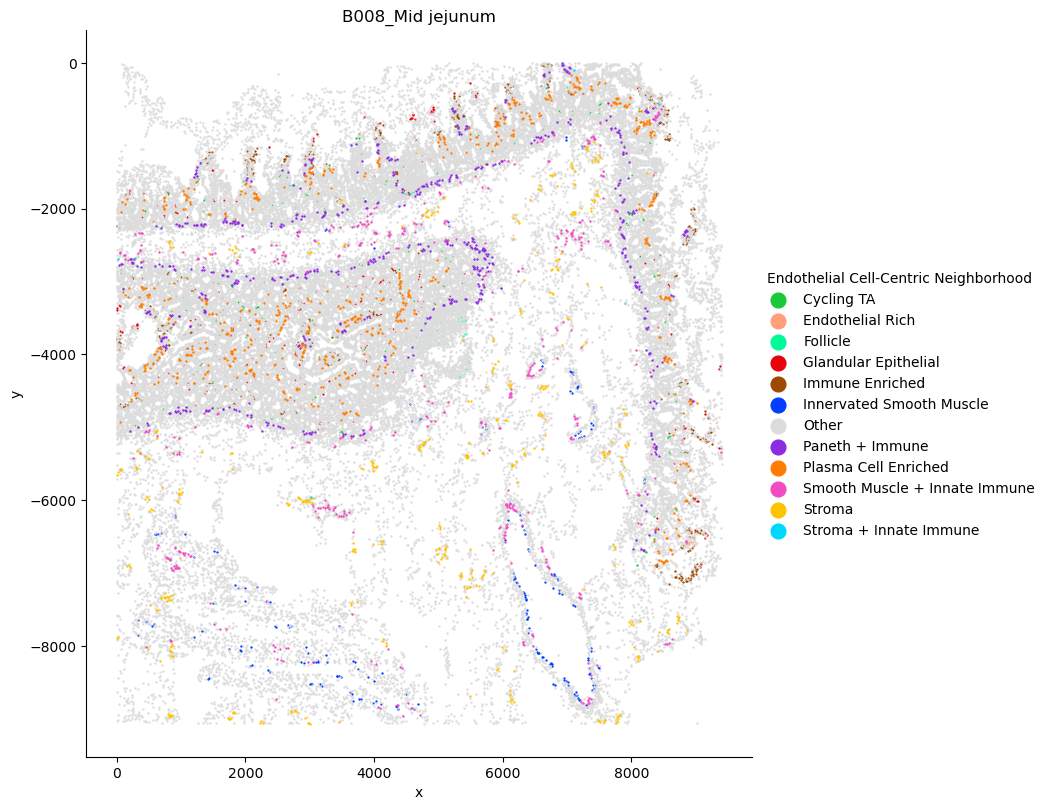

B008_Proximal jejunum


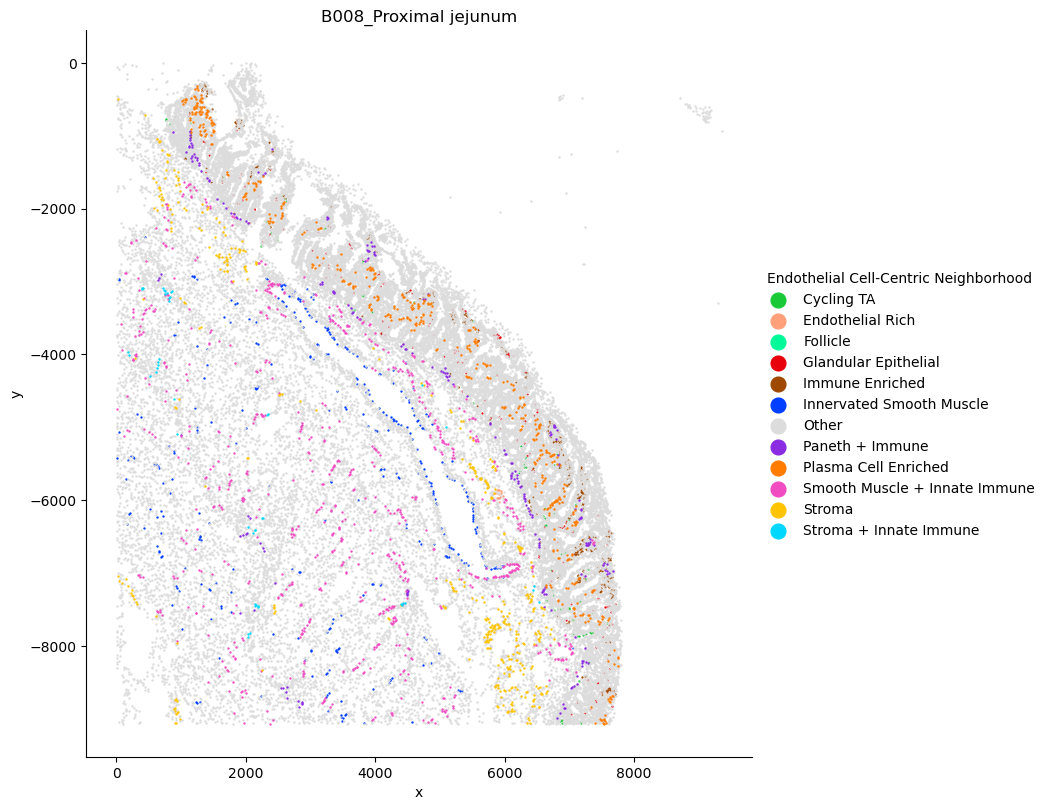

B008_Proximal jejunum_extra


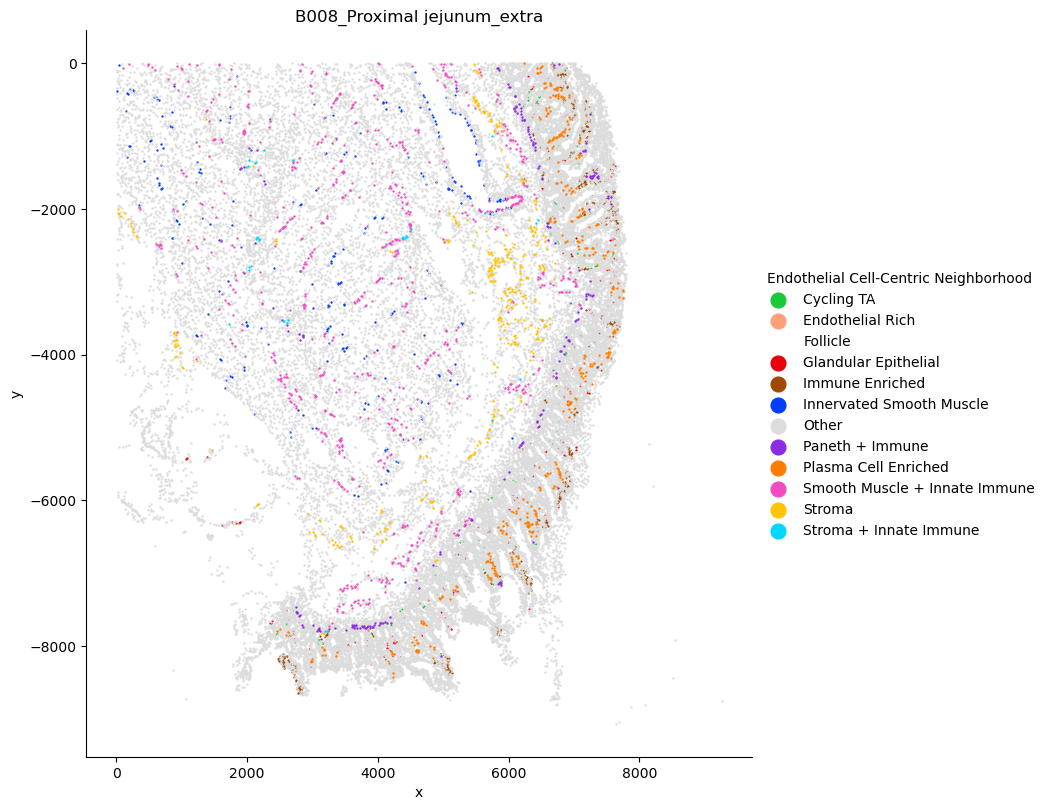

B008_Sigmoid


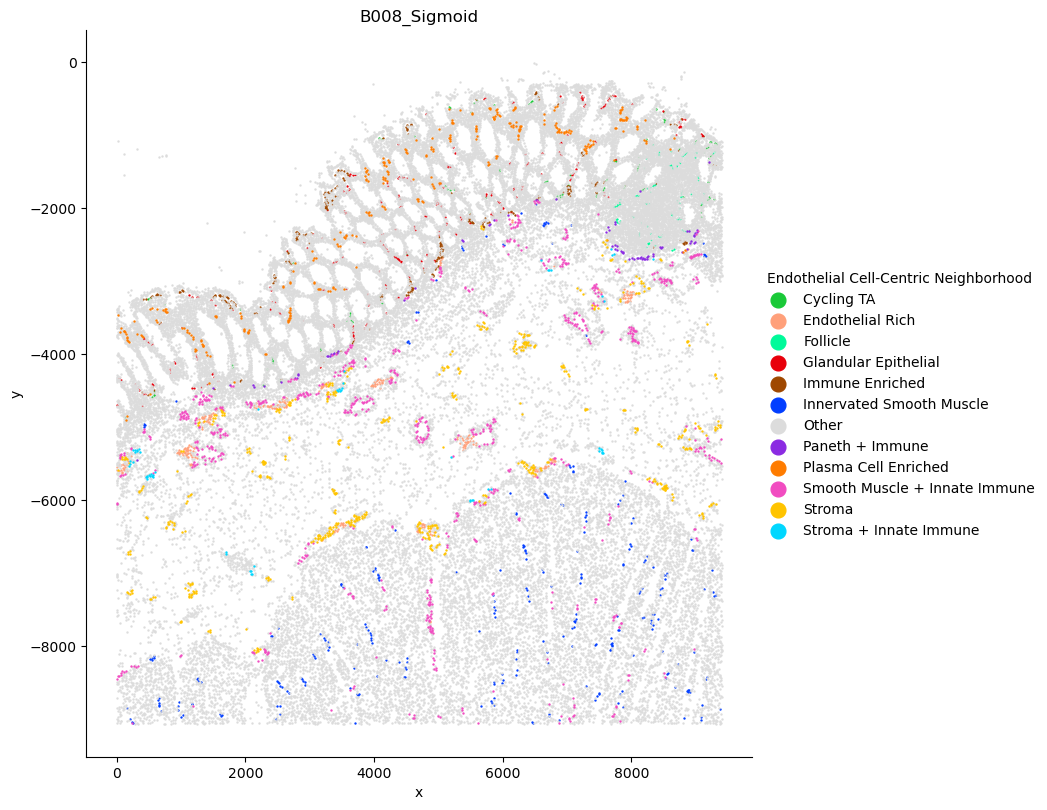

B008_Trans


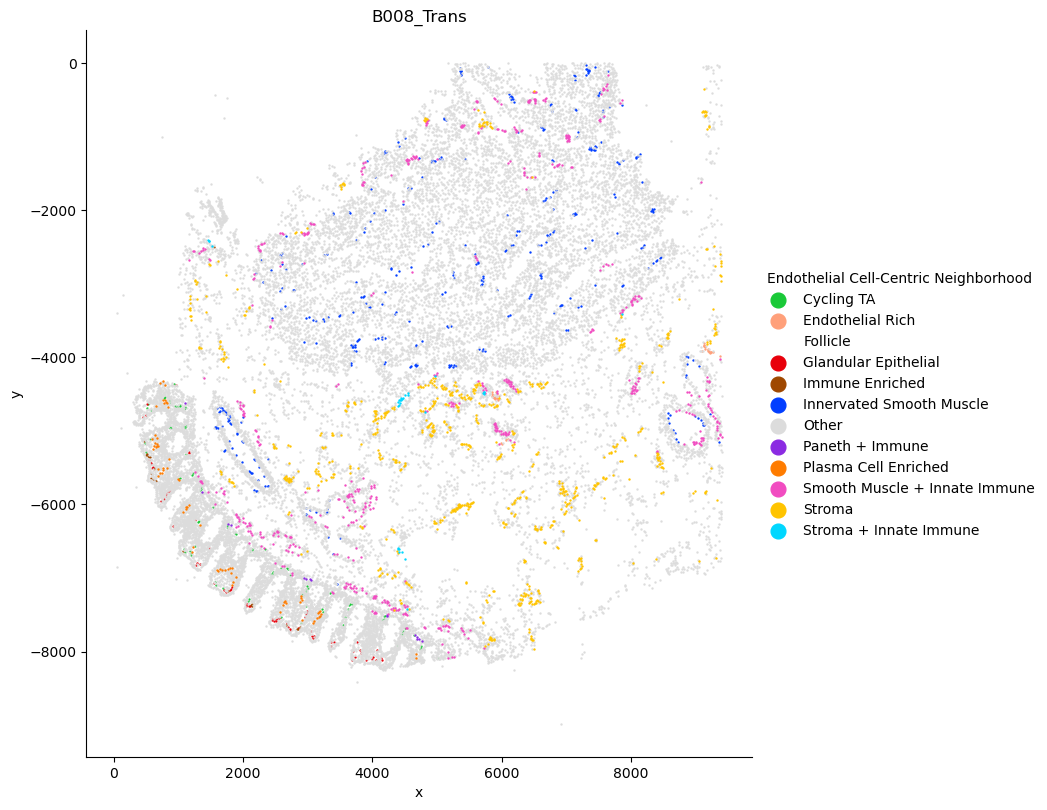

In [12]:
# Jodie
# Catplot of endothelial cell-centric neighborhoods
cells['Endothelial Cell-Centric Neighborhood'] = 'Other'  # Default category for cells not in type_cells

# Update the column for rows in type_cells
cells.loc[type_cells_merged.index, 'Endothelial Cell-Centric Neighborhood'] = type_cells_merged[neighborhood_name_merged]

unique_categories = cells['Endothelial Cell-Centric Neighborhood'].unique()
category_palette = sns.color_palette('bright', len(unique_categories))

# Create a custom palette with 'Other' explicitly set to gray
custom_palette = {**{cat: col for cat, col in zip(unique_categories, category_palette)}, 'Other': 'gainsboro'}
custom_palette['Follicle'] = 'mediumspringgreen'
custom_palette['Endothelial Rich'] = 'lightsalmon'

plt.rcParams["legend.markerscale"] = 15
sub_cells = cells.loc[cells['donor']=='B008']
figs = catplot2( sub_cells, X='x', Y='y', exp=reg, hue= 'Endothelial Cell-Centric Neighborhood',  # Updated column to highlight endothelial cells
    invert_y=True, size=2, figsize=8, exps=None, axis='on', scatter_kws={}, palette= custom_palette  # Use the custom color palette
)

In [13]:
# For attaching neighborhood colors to clustermap
cell_list = list(cells['Cell Type'].unique())
neigh_list = list(cells['Neighborhood'].unique())
endo_list = list(cells['Endothelial Cell-Centric Neighborhood'].unique())
color_list=list(custom_palette.values())
dict_cell = dict(zip(cell_list, color_list))
dict_neigh = dict(zip(neigh_list, color_list))
dict_endo = dict(zip(endo_list, color_list))

{'Other': 'gainsboro',
 'Plasma Cell Enriched': (1.0, 0.48627450980392156, 0.0),
 'Cycling TA': (0.10196078431372549, 0.788235294117647, 0.2196078431372549),
 'Glandular Epithelial': (0.9098039215686274, 0.0, 0.043137254901960784),
 'Paneth + Immune': (0.5450980392156862,
  0.16862745098039217,
  0.8862745098039215),
 'Immune Enriched': (0.6235294117647059, 0.2823529411764706, 0.0),
 'Smooth Muscle + Innate Immune': (0.9450980392156862,
  0.2980392156862745,
  0.7568627450980392),
 'Endothelial Rich': 'lightsalmon',
 'Stroma': (1.0, 0.7686274509803922, 0.0),
 'Stroma + Innate Immune': (0.0, 0.8431372549019608, 1.0),
 'Innervated Smooth Muscle': (0.00784313725490196, 0.24313725490196078, 1.0),
 'Follicle': 'mediumspringgreen'}

In [14]:
from matplotlib.colors import to_rgba

endo_data = pd.DataFrame({
    'Endothelial Cell-Centric Neighborhood':list(dict_endo.keys()),
    'color':list(dict_endo.values())
})
endo_data.set_index(keys='Endothelial Cell-Centric Neighborhood',inplace=True)

rgba_gainsboro = to_rgba('gainsboro')
rgba_lightsalmon = to_rgba('lightsalmon')
rgba_mediumspringgreen = to_rgba('mediumspringgreen')
endo_data.loc['Other', 'color'] = rgba_gainsboro
endo_data.loc['Endothelial Rich', 'color'] = rgba_lightsalmon
endo_data.loc['Follicle', 'color'] = rgba_mediumspringgreen
endo_data

,color
Endothelial Cell-Centric Neighborhood,
Other,"(0.8627450980392157, 0.8627450980392157, 0.862..."
Plasma Cell Enriched,"(1.0, 0.48627450980392156, 0.0)"
Cycling TA,"(0.10196078431372549, 0.788235294117647, 0.219..."
Glandular Epithelial,"(0.9098039215686274, 0.0, 0.043137254901960784)"
Paneth + Immune,"(0.5450980392156862, 0.16862745098039217, 0.88..."
Immune Enriched,"(0.6235294117647059, 0.2823529411764706, 0.0)"
Smooth Muscle + Innate Immune,"(0.9450980392156862, 0.2980392156862745, 0.756..."
Endothelial Rich,"(1.0, 0.6274509803921569, 0.47843137254901963,..."
Stroma,"(1.0, 0.7686274509803922, 0.0)"


In [15]:
def fc_out1(data, k_num, nbhd, type_nbhd_column):
    #Fill in based on above
    k = k_num
    n_neighborhoods = 1
    neighborhood_name = "neighborhood"+str(k)
    k_centroids = {}

    #choose windows with k calculated of interest
    windows2 = windows[k]
    windows2[cluster_col] = data[cluster_col]
    windows2[type_nbhd_column] = data[type_nbhd_column]

    #Only use T cell windows for example in cell_list
    cell_name = 'endothelial cells'
    #cell_list = ['Paneth','OLFM4+ Enterocyte']
    cell_list = ['Endothelial']
    nbhd_list = [nbhd]
    celltype_windows = windows2[windows2[cluster_col].isin(cell_list)]
    type_data = data[data[cluster_col].isin(cell_list)]


    # Jodie
    celltype_windows_nbhd = windows2[windows2[type_nbhd_column].isin(nbhd_list)] # for neighborhood rings analysis, otherwise use celltype_windows
    type_data_nbhd = data[data[type_nbhd_column].isin(nbhd_list)] # for neighborhood rings analysis, otherwise use type_data

    #Add labels
    km = MiniBatchKMeans(n_clusters = n_neighborhoods,random_state=0)

    labels = km.fit_predict(celltype_windows_nbhd[sum_cols].values)
    k_centroids[k] = km.cluster_centers_
    type_data_nbhd[neighborhood_name] = labels

    #Get out heat
    k_to_plot = k
    niche_clusters = (k_centroids[k_to_plot])
    tissue_avgs = values.mean(axis = 0)
    fc = np.log2(((niche_clusters+tissue_avgs)/(niche_clusters+tissue_avgs).sum(axis = 1, keepdims = True))/tissue_avgs)
    fc = pd.DataFrame(fc,columns = sum_cols)
    niche_aveg = pd.DataFrame(niche_clusters,columns = sum_cols)
    niche_avegg = niche_aveg/niche_aveg.sum(axis=1)[0]*100

    fc_output = fc.rename(index={0:k})
    niche_out = niche_avegg.rename(index={0:k})
    
    return fc_output, niche_out

In [16]:
# Jodie
# Copy of cells dataframe with endothelial cell-centric neighborhood column
cells_copy = cells.copy()
cells_copy.loc[type_cells_merged.index, neighborhood_name_merged] = type_cells_merged[neighborhood_name_merged]
cells_copy

,Unnamed: 0,MUC2,SOX9,MUC1,CD31,Synapto,CD49f,CD15,CHGA,CDX2,...,Neuroendocrine,Neutrophil,Paneth,Plasma,Smooth muscle,Stroma,TA,Cell Type Highlight,Endothelial Cell-Centric Neighborhood,neighborhood50_merged
0,0,-0.303994,-0.163727,-0.587608,-0.212903,0.164173,-0.664863,0.049305,0.003616,-0.377532,...,0,0,0,0,0,0,0,Other,Other,NaN
1,1,-0.301927,-0.491706,-0.500804,-0.243205,-0.142568,-0.664861,-0.182627,-0.117573,-0.182754,...,0,0,0,0,0,0,0,Other,Other,NaN
2,2,-0.302206,-0.547234,-0.510705,-0.235309,-0.217185,-0.622758,-0.296486,-0.091504,-0.268055,...,0,0,0,0,0,0,0,Other,Other,NaN
3,3,-0.304219,-0.613068,-0.584499,-0.243757,-0.266696,-0.658449,-0.299027,-0.121460,-0.345381,...,0,0,0,0,0,0,0,Other,Other,NaN
4,4,-0.294644,-0.615593,-0.570580,-0.247548,-0.042246,-0.642230,-0.299031,-0.121458,-0.377533,...,0,0,0,0,0,0,0,Other,Other,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2603212,2603212,0.351916,0.693827,-0.081489,-0.240643,0.008875,0.143445,0.373710,-0.097896,0.869830,...,0,0,0,0,0,0,0,Other,Other,NaN
2603213,2603213,0.233642,0.171892,0.141842,-0.236145,-0.097772,-0.099283,0.626185,-0.105545,0.092076,...,0,0,0,0,0,0,0,Other,Other,NaN
2603214,2603214,-0.212237,-0.280904,-0.197833,-0.245638,-0.152563,-0.125035,0.430416,-0.105787,-0.038327,...,0,0,0,0,0,0,0,Other,Other,NaN
2603215,2603215,-0.328666,0.607609,-0.180362,-0.247351,-0.143742,-0.169576,1.095596,-0.113879,0.370160,...,0,0,0,0,0,0,0,Other,Other,NaN


In [17]:
# Jodie
# Calculate concentric increasing neighborhoods for endothelial cells
os.environ['OMP_NUM_THREADS'] = '4' # For running on Windows with MKL

fc_list = []
fc_comb_list = []
niche_list = []
niche_comb_list = []
single_nbhd_list = []

for single_nbhd in cells_copy[neighborhood_name_merged].dropna().unique():
    single_nbhd_list.append(single_nbhd)
    df1, df2 = fc_out1(data=cells_copy, k_num=k, nbhd = single_nbhd, type_nbhd_column=neighborhood_name_merged) # df1 is fc_output, df2 is niche_out
    fc_list.append(df1)
    niche_list.append(df2)

    fc_comb = pd.concat(fc_list)
    fc_comb.index = single_nbhd_list
    niche_comb=pd.concat(niche_list)
    
print('Order of neighborhoods:', single_nbhd_list)
fc_comb

c:\Users\jodie\anaconda3\envs\nbhd_analysis\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\jodie\AppData\Local\Temp\ipykernel_16224\116272912.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  type_data_nbhd[neighborhood_name] = labels
c:\Users\jodie\anaconda3\envs\nbhd_analysis\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by s

Order of neighborhoods: ['Plasma Cell Enriched', 'Cycling TA', 'Glandular Epithelial', 'Paneth + Immune', 'Immune Enriched', 'Smooth Muscle + Innate Immune', 'Endothelial Rich', 'Stroma', 'Stroma + Innate Immune', 'Innervated Smooth Muscle', 'Follicle']


C:\Users\jodie\AppData\Local\Temp\ipykernel_16224\116272912.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  type_data_nbhd[neighborhood_name] = labels


,NK,Enterocyte,MUC1+ Enterocyte,TA,CD66+ Enterocyte,Paneth,Smooth muscle,M1 Macrophage,Goblet,Neuroendocrine,...,B,Neutrophil,Endothelial,Cycling TA,Plasma,CD4+ T cell,Stroma,Nerve,ICC,CD7+ Immune
Plasma Cell Enriched,-0.262479,-1.042892,-1.736601,-1.373318,-2.019272,-2.862958,-1.013497,1.007899,-0.834499,-0.981371,...,-1.164316,-0.075083,1.071950,-1.355442,2.377179,0.764953,-1.281696,-0.775397,0.301848,-1.241232
Cycling TA,0.115951,-0.481452,-0.358197,0.565537,0.235404,0.242282,-1.467015,0.717697,0.600756,0.479131,...,-0.628374,-0.333551,0.419500,1.400938,0.723432,0.744837,-1.077386,-0.225730,0.335025,-0.956389
Glandular Epithelial,0.253628,0.709877,1.919135,0.390761,-0.018776,-0.773537,-1.719541,0.633829,0.670235,0.582430,...,-1.138626,-0.330040,0.452090,-0.658479,-0.073426,-0.367350,-0.830717,-0.962036,-0.097591,-0.331808
Paneth + Immune,0.533795,-1.721641,-0.826764,-1.358297,-2.760837,1.828602,0.193241,0.947626,-1.844859,-0.796088,...,-1.161748,0.374312,1.165021,-1.411245,-0.651650,1.501510,-0.798994,0.545440,0.815130,-0.884984
Immune Enriched,-0.199416,-0.124335,-1.592838,-1.195295,-1.266641,-0.597508,-1.245442,1.974862,-0.889359,-0.439754,...,-1.908496,0.241212,1.530788,-1.793751,-0.310325,0.322978,-1.532792,-0.868996,0.184105,-0.056808
Smooth Muscle + Innate Immune,-1.216713,-3.638231,-1.951269,-3.531959,-4.017452,-2.323917,1.289673,-1.328645,-4.039368,-3.733462,...,-4.456715,0.655825,1.664428,-3.737673,-3.533829,-1.402260,0.880702,0.583510,0.508783,-2.970218
Endothelial Rich,-0.725221,-3.698036,-3.252999,-3.726298,-4.399677,-2.733295,0.296667,0.364374,-4.082206,-3.971753,...,-3.355211,0.772044,2.709570,-4.302714,-1.957539,-0.666523,-0.112600,-0.638906,0.340748,-2.919883
Stroma,-1.289061,-3.268692,-1.675970,-4.199768,-3.726182,-3.771571,-0.952424,-1.528709,-4.947706,-5.114635,...,-4.444435,0.146832,1.977872,-4.679711,-4.023915,-1.601613,2.073752,-0.341084,0.775186,-2.746208
Stroma + Innate Immune,-0.107981,-2.878906,-0.977041,-3.119881,-2.364160,-3.432134,-0.386018,-0.536516,-3.929689,-4.182290,...,-2.487493,3.062945,1.617088,-3.412122,-2.612882,-0.652915,1.087449,0.845371,1.017093,-2.575288
Innervated Smooth Muscle,-2.384390,-4.402654,-3.366523,-3.542611,-4.954781,-4.796836,2.081636,-2.288069,-4.530219,-5.136035,...,-4.960589,-0.618422,0.393641,-4.310787,-4.952772,-3.372174,0.104190,1.404571,-0.366329,-3.300087


In [18]:
missing_colors = endo_data.reindex(fc_comb.index)['color'].isna()
print(missing_colors.sum())  # Number of NaN values
print(missing_colors[missing_colors])

NameError: name 'fc_output_merged' is not defined

Text(0.47, 0.9, 'k=50')

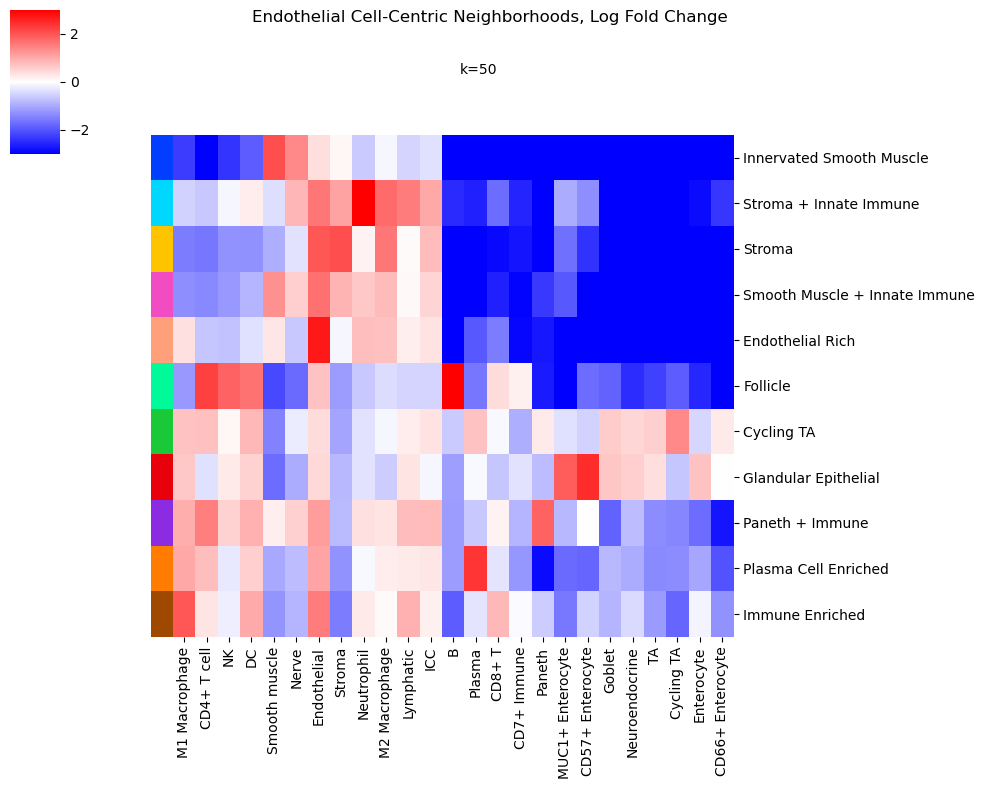

In [19]:
# #this plot shows the types of cells (ClusterIDs) in the different niches (0-9)
# k_to_plot = k
# niche_clusters = (k_centroids[k_to_plot])
# tissue_avgs = values.mean(axis = 0)
# fc = np.log2(((niche_clusters+tissue_avgs)/(niche_clusters+tissue_avgs).sum(axis = 1, keepdims = True))/tissue_avgs)
# fc = pd.DataFrame(fc,columns = sum_cols)
s=sns.clustermap(fc_comb, vmin =-3,vmax = 3,cmap = 'bwr', figsize=(10,8) ,row_colors=[endo_data.reindex(fc_comb.index)['color']])
s.ax_row_dendrogram.set_visible(False)
s.ax_col_dendrogram.set_visible(False)

# y_axis_ = s.dendrogram_row.reordered_ind
# x_axis_ = s.dendrogram_col.reordered_ind
# x_axis_labels_endo = fc_output.columns[x_axis_]
# y_axis_labels_endo = fc_output_merged.index[y_axis_]
# print(y_axis_labels_endo)

s.fig.suptitle('Endothelial Cell-Centric Neighborhoods, Log Fold Change')

s.fig.text(x=0.47, y=0.90, s = titlename)

In [ ]:
#modify figure size aesthetics for each neighborhood
plt.rcParams["legend.markerscale"] = 3
sub_cells = type_cells_merged.loc[type_cells_merged['donor']=='B008']
figs = catplot2(sub_cells,X = 'x',Y='y', exp= reg,
               hue = neighborhood_name_merged ,invert_y=False,size = 1,figsize=8, exps=None, axis='on', scatter_kws={})

#### UMAP visualization - cell type

In [36]:
type_cells['neigh_str'] = type_cells['neighborhood'+str(k)].astype(str)

C:\Users\jodie\AppData\Local\Temp\ipykernel_16224\130606113.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  type_cells['neigh_str'] = type_cells['neighborhood'+str(k)].astype(str)


In [53]:
type_cells_merged['neigh_str'] = type_cells_merged['neighborhood'+str(k)].astype(str)

Index(['Unnamed: 0', 'MUC2', 'SOX9', 'MUC1', 'CD31', 'Synapto', 'CD49f',
       'CD15', 'CHGA', 'CDX2',
       ...
       'Nerve', 'Neuroendocrine', 'Neutrophil', 'Paneth', 'Plasma',
       'Smooth muscle', 'Stroma', 'TA', 'neighborhood50',
       'neighborhood50_merged'],
      dtype='object', length=102)

In [54]:
markerlist = [
 'tissue', 'donor', 'region', 'Xcorr', 'Ycorr',
       'Tissue_location', 'array', 'Cell Type', 'Cell subtype', neighborhood_name_merged,
       'Neighborhood', 'Neighborhood_Ind', 'Neigh_sub',
       'NeighInd_sub', 'Community', 'Major Community', 'Tissue Segment',
]

In [38]:
#Add in markers for potential clustering later
markerlist.append('neighborhood'+str(k))
#markerlist.append('day harvested')

marker_df = type_cells[markerlist] # use type_cells for unmerged clusters


#turn into dictionary so I can extract values later for dataframe
tfc = fc.T
#key 1 is neighborhood number, #key 2 is the cell type
dict_tfc = tfc.to_dict()

#Map back with neighborhood number
for cell_type_unique in dict_tfc[0].keys():
    marker_df[str('Enriched ')+cell_type_unique] = marker_df['neighborhood'+str(k)].apply(lambda x:dict_tfc[x][cell_type_unique])



C:\Users\jodie\AppData\Local\Temp\ipykernel_16224\4094938612.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  marker_df[str('Enriched ')+cell_type_unique] = marker_df['neighborhood'+str(k)].apply(lambda x:dict_tfc[x][cell_type_unique])
C:\Users\jodie\AppData\Local\Temp\ipykernel_16224\4094938612.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  marker_df[str('Enriched ')+cell_type_unique] = marker_df['neighborhood'+str(k)].apply(lambda x:dict_tfc[x][cell_type_unique])
C:\Users\jodie\AppData\Local\Tem

In [ ]:
marker_df.loc[:,['Neighborhood', 'Neighborhood_Ind', 'Neigh_sub', 'NeighInd_sub', 'Community']]

In [ ]:
marker_df['neighborhood'+str(k)]

In [ ]:
print(marker_df['Community'].unique())

In [40]:
comb_df = pd.concat([celltype_windows, marker_df], axis=1)
comb_df

,x,y,unique_region,Cell Type,NK,Enterocyte,MUC1+ Enterocyte,TA,CD66+ Enterocyte,Paneth,...,Enriched B,Enriched Neutrophil,Enriched Endothelial,Enriched Cycling TA,Enriched Plasma,Enriched CD4+ T cell,Enriched Stroma,Enriched Nerve,Enriched ICC,Enriched CD7+ Immune
45963,9.0,22.0,B004_Ascending,Endothelial,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.458488,0.499288,1.439506,-1.048138,0.074797,0.147401,0.38672,0.040167,0.415058,-1.159586
45964,27.0,30.0,B004_Ascending,Endothelial,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.458488,0.499288,1.439506,-1.048138,0.074797,0.147401,0.38672,0.040167,0.415058,-1.159586
45965,55.0,23.0,B004_Ascending,Endothelial,0.0,0.0,1.0,0.0,0.0,0.0,...,-0.458488,0.499288,1.439506,-1.048138,0.074797,0.147401,0.38672,0.040167,0.415058,-1.159586
45966,59.0,37.0,B004_Ascending,Endothelial,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.458488,0.499288,1.439506,-1.048138,0.074797,0.147401,0.38672,0.040167,0.415058,-1.159586
45967,69.0,22.0,B004_Ascending,Endothelial,0.0,0.0,1.0,0.0,0.0,0.0,...,-0.458488,0.499288,1.439506,-1.048138,0.074797,0.147401,0.38672,0.040167,0.415058,-1.159586
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2595523,4260.0,7367.0,B008_Trans,Endothelial,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.458488,0.499288,1.439506,-1.048138,0.074797,0.147401,0.38672,0.040167,0.415058,-1.159586
2595524,9300.0,4823.0,B008_Trans,Endothelial,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.458488,0.499288,1.439506,-1.048138,0.074797,0.147401,0.38672,0.040167,0.415058,-1.159586
2595525,7584.0,715.0,B008_Trans,Endothelial,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.458488,0.499288,1.439506,-1.048138,0.074797,0.147401,0.38672,0.040167,0.415058,-1.159586
2595526,1972.0,4707.0,B008_Trans,Endothelial,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.458488,0.499288,1.439506,-1.048138,0.074797,0.147401,0.38672,0.040167,0.415058,-1.159586


In [ ]:
#Read in Data and Rename ClusterID with Named Values
df = comb_df.copy()
#make neighborhood not an integer
df['neighborhood'+str(k)] = df['neighborhood'+str(k)].astype(str)

45963      0
45964      0
45965      0
45966      0
45967      0
          ..
2595523    0
2595524    0
2595525    0
2595526    0
2595527    0
Name: neighborhood50, Length: 187420, dtype: object

In [42]:
cell_enr = [
 'Enriched NK', 'Enriched Enterocyte',
       'Enriched CD66+ Enterocyte', 'Enriched TA',
       'Enriched MUC1+ Enterocyte',
       'Enriched Smooth muscle', 'Enriched Paneth', 'Enriched M1 Macrophage',
       'Enriched Goblet', 'Enriched Neuroendocrine',
       'Enriched CD57+ Enterocyte', 'Enriched Lymphatic', 'Enriched CD8+ T',
       'Enriched DC', 'Enriched M2 Macrophage', 'Enriched B',
       'Enriched Neutrophil', 'Enriched Endothelial', 'Enriched Cycling TA',
       'Enriched Plasma', 'Enriched CD4+ T cell', 'Enriched Stroma',
       'Enriched Nerve', 'Enriched ICC', 'Enriched CD7+ Immune',
]


collist = [
'x', 'y', 'unique_region', 'Cell Type','tissue',
       'donor', 'region', 'Xcorr', 'Ycorr', 'Tissue_location', 'array',
       'Cell subtype', 'Neighborhood', 'Neighborhood_Ind',
       'Neigh_sub', 'NeighInd_sub', 'Community', 'Major Community',
       'Tissue Segment'
 ]

#Prepare for making into anndata format so that obs and data are separate
windows_list = [
 'NK', 'Enterocyte',
       'CD66+ Enterocyte', 'TA', 'MUC1+ Enterocyte',
       'Smooth muscle', 'Paneth', 'M1 Macrophage', 'Goblet', 'Neuroendocrine',
       'CD57+ Enterocyte', 'Lymphatic', 'CD8+ T', 'DC', 'M2 Macrophage', 'B',
       'Neutrophil', 'Endothelial', 'Cycling TA', 'Plasma', 'CD4+ T cell',
       'Stroma', 'Nerve', 'ICC', 'CD7+ Immune']

In [43]:
df1 = df.drop(columns = collist ) #USER INPUT
df1.columns

Index(['NK', 'Enterocyte', 'MUC1+ Enterocyte', 'TA', 'CD66+ Enterocyte',
       'Paneth', 'Smooth muscle', 'M1 Macrophage', 'Goblet', 'Neuroendocrine',
       'CD57+ Enterocyte', 'Lymphatic', 'CD8+ T', 'DC', 'M2 Macrophage', 'B',
       'Neutrophil', 'Endothelial', 'Cycling TA', 'Plasma', 'CD4+ T cell',
       'Stroma', 'Nerve', 'ICC', 'CD7+ Immune', 'neighborhood50_merged',
       'neighborhood50', 'Enriched NK', 'Enriched Enterocyte',
       'Enriched MUC1+ Enterocyte', 'Enriched TA', 'Enriched CD66+ Enterocyte',
       'Enriched Paneth', 'Enriched Smooth muscle', 'Enriched M1 Macrophage',
       'Enriched Goblet', 'Enriched Neuroendocrine',
       'Enriched CD57+ Enterocyte', 'Enriched Lymphatic', 'Enriched CD8+ T',
       'Enriched DC', 'Enriched M2 Macrophage', 'Enriched B',
       'Enriched Neutrophil', 'Enriched Endothelial', 'Enriched Cycling TA',
       'Enriched Plasma', 'Enriched CD4+ T cell', 'Enriched Stroma',
       'Enriched Nerve', 'Enriched ICC', 'Enriched CD7+ Immune'

In [44]:
#Prepare for making into anndata format
dfw = df1[windows_list]
dfw.columns

Index(['NK', 'Enterocyte', 'CD66+ Enterocyte', 'TA', 'MUC1+ Enterocyte',
       'Smooth muscle', 'Paneth', 'M1 Macrophage', 'Goblet', 'Neuroendocrine',
       'CD57+ Enterocyte', 'Lymphatic', 'CD8+ T', 'DC', 'M2 Macrophage', 'B',
       'Neutrophil', 'Endothelial', 'Cycling TA', 'Plasma', 'CD4+ T cell',
       'Stroma', 'Nerve', 'ICC', 'CD7+ Immune'],
      dtype='object')

In [45]:
#Convert to anndata format
adata_w = sc.AnnData(dfw)
collist.extend(cell_enr)

adata_w.obs = df[collist]
adata_w

c:\Users\jodie\anaconda3\envs\nbhd_analysis\Lib\site-packages\anndata\_core\aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
c:\Users\jodie\anaconda3\envs\nbhd_analysis\Lib\site-packages\anndata\_core\anndata.py:747: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    [45963, 45964, 45965, 45966, 45967]

    Inferred to be: integer

  value_idx = self._prep_dim_index(value.index, attr)


AnnData object with n_obs × n_vars = 187420 × 25
    obs: 'x', 'y', 'unique_region', 'Cell Type', 'Cell Type', 'tissue', 'donor', 'region', 'Xcorr', 'Ycorr', 'Tissue_location', 'array', 'Cell subtype', 'Neighborhood', 'Neighborhood', 'Neighborhood_Ind', 'Neigh_sub', 'NeighInd_sub', 'Community', 'Major Community', 'Tissue Segment', 'Enriched NK', 'Enriched Enterocyte', 'Enriched CD66+ Enterocyte', 'Enriched TA', 'Enriched MUC1+ Enterocyte', 'Enriched Smooth muscle', 'Enriched Paneth', 'Enriched M1 Macrophage', 'Enriched Goblet', 'Enriched Neuroendocrine', 'Enriched CD57+ Enterocyte', 'Enriched Lymphatic', 'Enriched CD8+ T', 'Enriched DC', 'Enriched M2 Macrophage', 'Enriched B', 'Enriched Neutrophil', 'Enriched Endothelial', 'Enriched Cycling TA', 'Enriched Plasma', 'Enriched CD4+ T cell', 'Enriched Stroma', 'Enriched Nerve', 'Enriched ICC', 'Enriched CD7+ Immune'

In [46]:
sc.settings.set_figure_params(dpi=80, facecolor='white',dpi_save=300, transparent=True, frameon=False, fontsize=22)
plt.rcParams["legend.markerscale"] = 1

c:\Users\jodie\anaconda3\envs\nbhd_analysis\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\jodie\anaconda3\envs\nbhd_analysis\Lib\site-packages\anndata\_core\anndata.py:1145: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[key] = c
c:\Users\jodie\anaconda3\envs\nbhd_analysis\Lib\site-packages\anndata\_core\anndata.py:1145: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/in

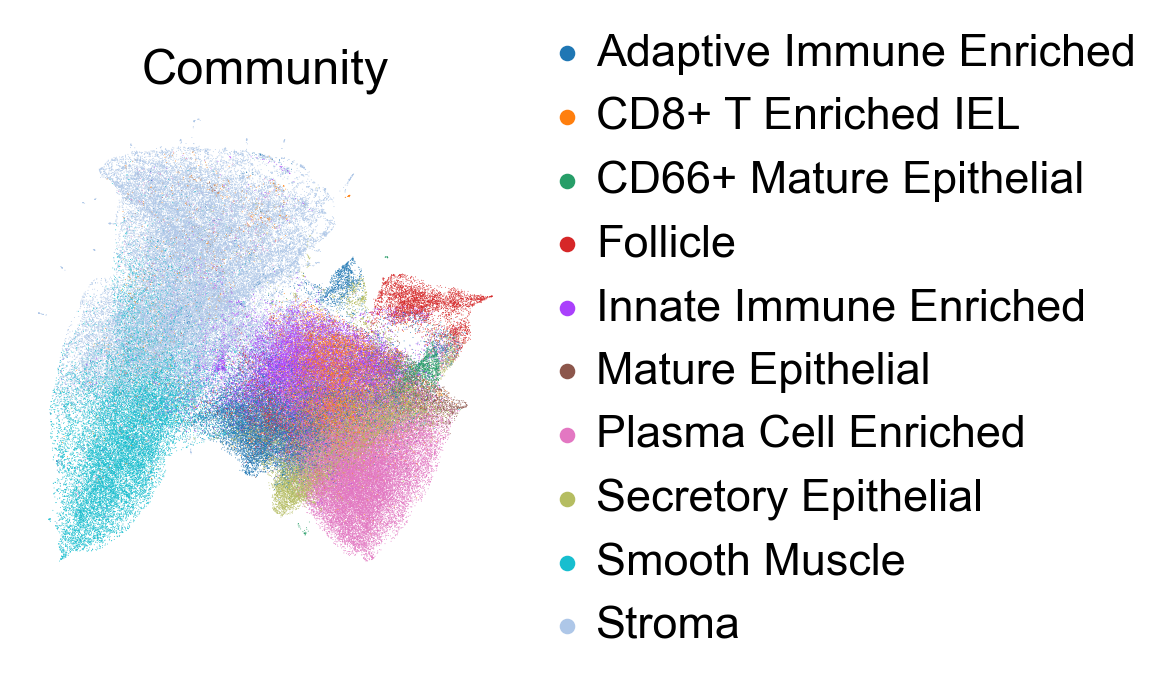

In [47]:
#Compute the neighborhood relations of single cells.
#The size of local neighborhood (in terms of number of neighboring data points) used for
#manifold approximation. Larger values result in more global views of the manifold, while
#smaller values result in more local data being preserved. In general values should be in
#the range 2 to 100 and a good average is 10
#13 is good
sc.pp.neighbors(adata_w, n_neighbors=20)
sc.tl.umap(adata_w)
sc.pl.umap(adata_w, color ='Community',)

In [ ]:
sc.pl.umap(adata_w, color ='Tissue_location',)

In [ ]:
! pip3 install leidenalg

In [ ]:
sc.tl.leiden(adata_w, resolution=0.5)
# sc.tl.leiden(adata_w, resolution=0.5, flavor="igraph", n_iterations=2, directed=False)
sc.pl.umap(adata_w, color ='leiden')


In [ ]:
#Choose this information and input based on above
ks = [5,10,30,50,100,300] # k=5 means it collects 5 nearest neighbors for each center cell
path_to_data = '/Users/jodie/OneDrive/Documents/Duke/Hickey Lab/23_09_CODEX_HuBMAP_alldata_Dryad_merged.csv'

X = 'x'
Y = 'y'
reg = 'unique_region'
file_type = 'csv'

cellhier_path = '/Users/jodie/OneDrive/Documents/Python Scripts/Hierarchical-Tissue-Unit-Annotation'
sys.path.append(cellhier_path)
from cellhier.general import *
from cellhier.plot_john import *
from cellhier.knn_graph_neighborhood2 import *  # Imports everything

cluster_col = neighborhood_name
keep_cols = [X,Y,reg,cluster_col]
save_path = '/Users/jodie/OneDrive/Documents/Duke/Hickey Lab/panorgan'
#Import Data

n_neighbors = max(ks)


type_cells = pd.concat([type_cells,pd.get_dummies(type_cells[cluster_col], dtype=int)],axis=1)
sum_cols = type_cells[cluster_col].unique()
values = type_cells[sum_cols].values



#### Rings Analysis

Filter windows to only contain 1 cell type and perform neighborhood analysis to get 1 cluster for each $k$.

In [20]:
os.environ['OMP_NUM_THREADS'] = '4' # For running on Windows with MKL

#Fill in based on above
k = 50
n_neighborhoods = 1
neighborhood_name = "neighborhood"+str(k)
k_centroids = {}

#choose windows with k calculated of interest
windows2 = windows[k]
windows2[cluster_col] = cells[cluster_col]
print(cluster_col)

#Only use T cell windows for example in cell_list
cell_name = 'endothelial cells'
#cell_list = ['Paneth','OLFM4+ Enterocyte']
cell_list = ['Endothelial']
celltype_windows = windows2[windows2[cluster_col].isin(cell_list)]
type_cells = cells[cells[cluster_col].isin(cell_list)]

#Add lables
km = MiniBatchKMeans(n_clusters = n_neighborhoods,random_state=0)
labels = km.fit_predict(celltype_windows[sum_cols].values)
k_centroids[k] = km.cluster_centers_
type_cells[neighborhood_name] = labels

#Get out heat
k_to_plot = k
niche_clusters = (k_centroids[k_to_plot])
tissue_avgs = values.mean(axis = 0)
fc = np.log2(((niche_clusters+tissue_avgs)/(niche_clusters+tissue_avgs).sum(axis = 1, keepdims = True))/tissue_avgs)
fc = pd.DataFrame(fc,columns = sum_cols)
fc_output = fc.rename(index={0:k})


Cell Type


c:\Users\jodie\anaconda3\envs\nbhd_analysis\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\jodie\AppData\Local\Temp\ipykernel_16224\1196949165.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  type_cells[neighborhood_name] = labels


In [21]:
def fc_out(data, k_num, nbhd):
    #Fill in based on above
    k = k_num
    n_neighborhoods = 1
    neighborhood_name = "neighborhood"+str(k)
    k_centroids = {}

    #choose windows with k calculated of interest
    windows2 = windows[k]
    windows2[cluster_col] = data[cluster_col]
    windows2['Endothelial Neighborhood'] = data['Endothelial Neighborhood']

    #Only use T cell windows for example in cell_list
    cell_name = 'endothelial cells'
    #cell_list = ['Paneth','OLFM4+ Enterocyte']
    cell_list = ['Endothelial']
    nbhd_list = [nbhd]
    celltype_windows = windows2[windows2[cluster_col].isin(cell_list)]
    type_data = data[data[cluster_col].isin(cell_list)]


    # Jodie
    nbhd_name = 'Endothelial Neighborhood'
    celltype_windows_nbhd = windows2[windows2[nbhd_name].isin(nbhd_list)] # for neighborhood rings analysis, otherwise use celltype_windows
    type_data_nbhd = data[data[nbhd_name].isin(nbhd_list)] # for neighborhood rings analysis, otherwise use type_data

    #Add labels
    km = MiniBatchKMeans(n_clusters = n_neighborhoods,random_state=0)

    labels = km.fit_predict(celltype_windows_nbhd[sum_cols].values)
    k_centroids[k] = km.cluster_centers_
    type_data_nbhd[neighborhood_name] = labels

    #Get out heat
    k_to_plot = k
    niche_clusters = (k_centroids[k_to_plot])
    tissue_avgs = values.mean(axis = 0)
    fc = np.log2(((niche_clusters+tissue_avgs)/(niche_clusters+tissue_avgs).sum(axis = 1, keepdims = True))/tissue_avgs)
    fc = pd.DataFrame(fc,columns = sum_cols)
    niche_aveg = pd.DataFrame(niche_clusters,columns = sum_cols)
    niche_avegg = niche_aveg/niche_aveg.sum(axis=1)[0]*100

    fc_output = fc.rename(index={0:k})
    niche_out = niche_avegg.rename(index={0:k})
    return fc_output, niche_out

 Calculate concentric increasing neighbourhoods around an endothelial cell to generate cellular neighbourhoods for endothelial cells at increasing radii.

In [22]:
# Jodie
# Copy of cells dataframe with endothelial cell-centric neighborhood column

cells_copy = cells.copy()
cells_copy.loc[type_cells.index, 'Endothelial Neighborhood'] = type_cells_merged[neighborhood_name_merged]
cells_copy

,Unnamed: 0,MUC2,SOX9,MUC1,CD31,Synapto,CD49f,CD15,CHGA,CDX2,...,Neuroendocrine,Neutrophil,Paneth,Plasma,Smooth muscle,Stroma,TA,Cell Type Highlight,Endothelial Cell-Centric Neighborhood,Endothelial Neighborhood
0,0,-0.303994,-0.163727,-0.587608,-0.212903,0.164173,-0.664863,0.049305,0.003616,-0.377532,...,0,0,0,0,0,0,0,Other,Other,NaN
1,1,-0.301927,-0.491706,-0.500804,-0.243205,-0.142568,-0.664861,-0.182627,-0.117573,-0.182754,...,0,0,0,0,0,0,0,Other,Other,NaN
2,2,-0.302206,-0.547234,-0.510705,-0.235309,-0.217185,-0.622758,-0.296486,-0.091504,-0.268055,...,0,0,0,0,0,0,0,Other,Other,NaN
3,3,-0.304219,-0.613068,-0.584499,-0.243757,-0.266696,-0.658449,-0.299027,-0.121460,-0.345381,...,0,0,0,0,0,0,0,Other,Other,NaN
4,4,-0.294644,-0.615593,-0.570580,-0.247548,-0.042246,-0.642230,-0.299031,-0.121458,-0.377533,...,0,0,0,0,0,0,0,Other,Other,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2603212,2603212,0.351916,0.693827,-0.081489,-0.240643,0.008875,0.143445,0.373710,-0.097896,0.869830,...,0,0,0,0,0,0,0,Other,Other,NaN
2603213,2603213,0.233642,0.171892,0.141842,-0.236145,-0.097772,-0.099283,0.626185,-0.105545,0.092076,...,0,0,0,0,0,0,0,Other,Other,NaN
2603214,2603214,-0.212237,-0.280904,-0.197833,-0.245638,-0.152563,-0.125035,0.430416,-0.105787,-0.038327,...,0,0,0,0,0,0,0,Other,Other,NaN
2603215,2603215,-0.328666,0.607609,-0.180362,-0.247351,-0.143742,-0.169576,1.095596,-0.113879,0.370160,...,0,0,0,0,0,0,0,Other,Other,NaN


In [23]:
# Jodie
# Calculate concentric increasing neighborhoods for endothelial cells
os.environ['OMP_NUM_THREADS'] = '4' # For running on Windows with MKL

fc_list = []
fc_comb_list = []
niche_list = []
niche_comb_list = []
single_nbhd_list = []

for single_nbhd in cells_copy['Endothelial Neighborhood'].dropna().unique():
    single_nbhd_list.append(single_nbhd)
    for kn in ks:
        df1, df2 = fc_out(data=cells_copy, k_num=kn, nbhd = single_nbhd) # df1 is fc_output, df2 is niche_out
        new_neigh = 'neighborhood'+str(kn)
        fc_list.append(df1)
        niche_list.append(df2)

    fc_comb = pd.concat(fc_list)
    niche_comb=pd.concat(niche_list)

    fc_comb_list.append(fc_comb)
    niche_comb_list.append(niche_comb)
    
print('Order of neighborhoods:', single_nbhd_list)
fc_comb

c:\Users\jodie\anaconda3\envs\nbhd_analysis\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
C:\Users\jodie\AppData\Local\Temp\ipykernel_16224\2118288602.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  type_data_nbhd[neighborhood_name] = labels
c:\Users\jodie\anaconda3\envs\nbhd_analysis\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by 

Order of neighborhoods: ['Plasma Cell Enriched', 'Cycling TA', 'Glandular Epithelial', 'Paneth + Immune', 'Immune Enriched', 'Smooth Muscle + Innate Immune', 'Endothelial Rich', 'Stroma', 'Stroma + Innate Immune', 'Innervated Smooth Muscle', 'Follicle']


C:\Users\jodie\AppData\Local\Temp\ipykernel_16224\2118288602.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  type_data_nbhd[neighborhood_name] = labels


,NK,Enterocyte,MUC1+ Enterocyte,TA,CD66+ Enterocyte,Paneth,Smooth muscle,M1 Macrophage,Goblet,Neuroendocrine,...,B,Neutrophil,Endothelial,Cycling TA,Plasma,CD4+ T cell,Stroma,Nerve,ICC,CD7+ Immune
5,-0.259811,-1.958388,-2.157634,-2.231632,-2.192193,-2.488346,-1.327330,0.678595,-2.102320,-1.960472,...,-1.319969,-0.009847,2.442503,-2.225161,1.782627,0.454343,-1.256151,-0.824373,0.244145,-1.606407
10,-0.107902,-2.008767,-2.688033,-2.456906,-2.463158,-3.039726,-1.217520,0.919805,-2.078838,-2.018173,...,-1.228993,-0.010170,2.045584,-2.415239,2.193497,0.697035,-1.245377,-0.790408,0.378657,-1.601664
30,-0.141134,-1.433945,-2.226194,-1.859093,-2.347992,-3.172367,-1.030203,1.027841,-1.269757,-1.419414,...,-1.143548,-0.047174,1.361075,-1.856629,2.414060,0.805143,-1.275111,-0.746749,0.359618,-1.404855
50,-0.262479,-1.042892,-1.736601,-1.373318,-2.019272,-2.862958,-1.013497,1.007899,-0.834499,-0.981371,...,-1.164316,-0.075083,1.071950,-1.355442,2.377179,0.764953,-1.281696,-0.775397,0.301848,-1.241232
100,-0.315171,-0.507118,-1.177272,-0.770110,-1.572926,-2.184685,-1.070035,0.951308,-0.260194,-0.491503,...,-1.228575,-0.245165,0.764394,-0.744824,2.167929,0.645600,-1.339879,-0.887133,0.202395,-1.034476
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10,1.531646,-2.611687,-2.588665,-2.540360,-2.705532,-2.636414,-1.978569,-1.453578,-2.201320,-2.685752,...,4.009368,-0.197863,1.818051,-1.935056,-1.478285,1.865697,-1.258686,-1.473064,-0.629188,0.143455
30,1.772745,-2.662037,-3.002717,-2.394458,-3.252540,-2.827940,-2.131208,-1.247738,-2.050078,-2.666298,...,4.253245,-0.430627,1.037010,-1.912848,-1.568808,2.182732,-1.211333,-1.674444,-0.531100,0.161642
50,1.832085,-2.532440,-3.063178,-2.245864,-3.368291,-2.694894,-2.156005,-1.199797,-1.834544,-2.462915,...,4.295724,-0.651424,0.721345,-1.902268,-1.616029,2.236666,-1.157532,-1.736106,-0.492336,0.183860
100,1.814949,-2.215457,-2.915900,-1.995064,-3.249881,-2.366182,-2.115429,-1.178786,-1.515459,-2.144199,...,4.283526,-0.918893,0.386007,-1.779204,-1.624296,2.260845,-1.100951,-1.798467,-0.484711,0.210911


In [ ]:
os.environ['OMP_NUM_THREADS'] = '4' # For running on Windows with MKL

fc_list = []
niche_list = []
for kn in ks:
    df1, df2 = fc_out(data=cells, k_num=kn) # df1 is fc_output, df2 is niche_out
    new_neigh = 'neighborhood'+str(kn)
    fc_list.append(df1)
    niche_list.append(df2)

fc_comb = pd.concat(fc_list)
niche_comb=pd.concat(niche_list)

In [24]:
plt.style.use(['default'])
#GENERAL GRAPH SETTINGs
#font size of graph
SMALL_SIZE = 14
MEDIUM_SIZE = 16
BIGGER_SIZE = 18

#Settings for graph
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [ ]:
# Jodie
# Functions for updating indices of fc_comb (may or may not be necessary to use)

def update_index(arr_fc, nbhds, suffixes):
    arr_fc_index = list(arr_fc.index)
    for i in range(0, len(arr_fc_index), nbhds):  # Start from 0 and step by n
        arr_fc_index[i] = 0

    for idx, suffix in enumerate(suffixes):
        start = idx * nbhds
        end = start + nbhds
        for i in range(start, min(end, len(arr_fc_index))):
            arr_fc_index[i] = str(arr_fc_index[i]) + '_' + str(suffix)
    
    return  arr_fc_index

# Create a mapping from cluster ID to above ordering used for single-cell type neighborhood analysis(good for numbered clusters)
def axis_match(underscore_list, order_list):
    prefix_map = {}
    for entry in underscore_list:
        prefix = int(entry.split('_')[0])  # Extract the numeric prefix
        if prefix not in prefix_map:
            prefix_map[prefix] = []
        prefix_map[prefix].append(entry)

    # Reorder based on order_list
    reordered_list = []
    for num in order_list:
        if num in prefix_map:
            reordered_list.extend(prefix_map[num])  # Add all entries for this prefix

    return reordered_list


In [ ]:
fc_comb_merged_sorted = fc_comb_merged_sorted[x_axis_labels_endo]
fc_comb_merged_sorted = fc_comb_merged_sorted.loc[y_axis_labels_endo]
fc_comb_merged_sorted

In [25]:
single_nbhd_labels = [item for item in single_nbhd_list for _ in range(6)]

[Text(1, 0, 'Plasma Cell Enriched'),
 Text(1, 6, 'Cycling TA'),
 Text(1, 12, 'Glandular Epithelial'),
 Text(1, 18, 'Paneth + Immune'),
 Text(1, 24, 'Immune Enriched'),
 Text(1, 30, 'Smooth Muscle + Innate Immune'),
 Text(1, 36, 'Endothelial Rich'),
 Text(1, 42, 'Stroma'),
 Text(1, 48, 'Stroma + Innate Immune'),
 Text(1, 54, 'Innervated Smooth Muscle'),
 Text(1, 60, 'Follicle')]

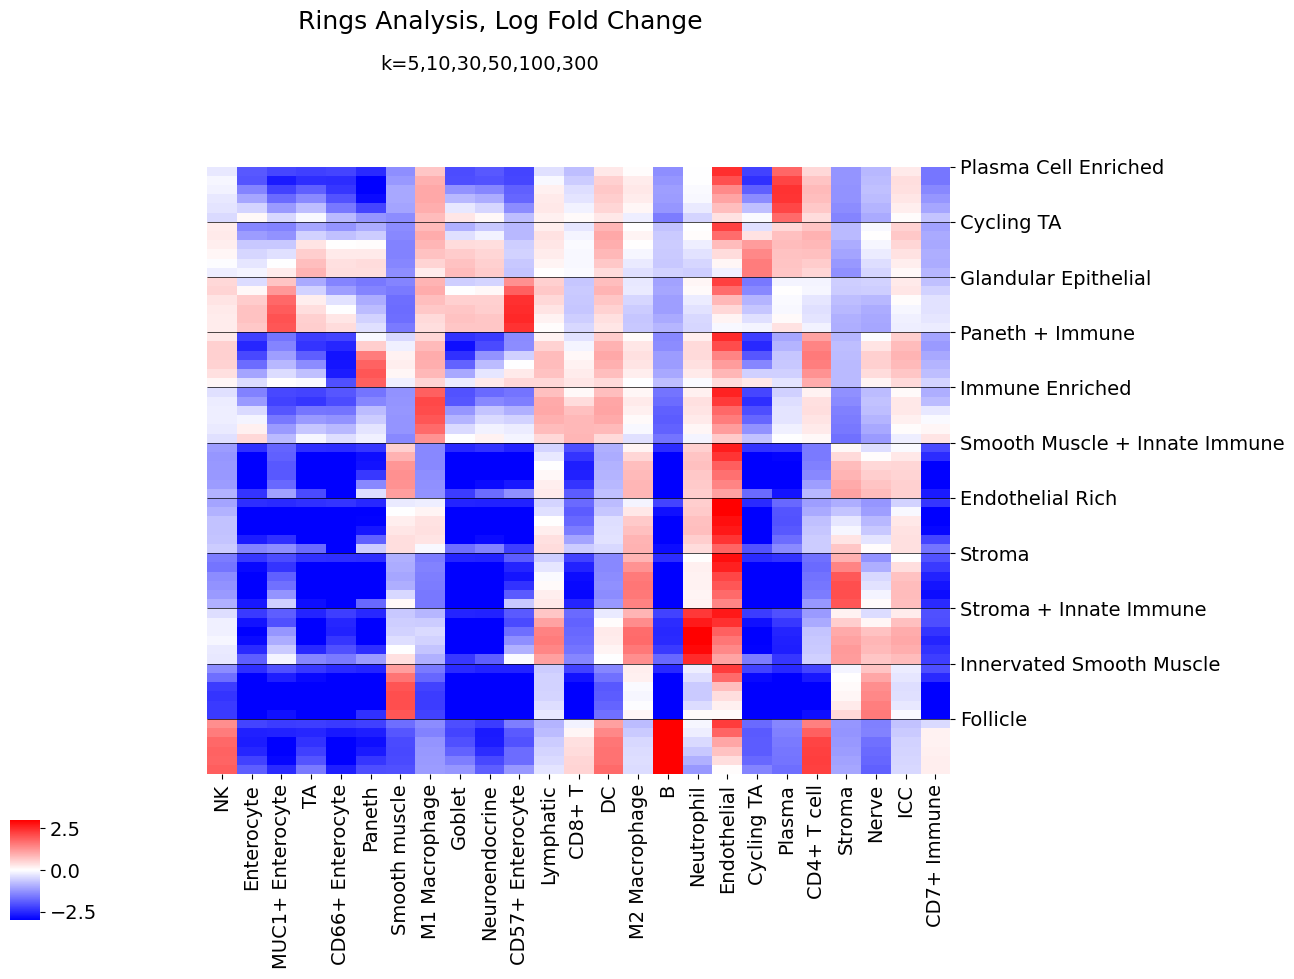

In [26]:
# looking at log fold change enrichment
s=sns.clustermap(fc_comb, vmin =-3,vmax = 3,cmap = 'bwr', figsize=(10,10),cbar_pos=(0.01,0.07,0.03,0.1), row_cluster=False, col_cluster=False) # , row_colors=[endo_data.reindex(fc_comb_merged_sorted.index)['color']])
s.ax_row_dendrogram.set_visible(False)
s.ax_col_dendrogram.set_visible(False)
s.fig.suptitle('Rings Analysis, Log Fold Change')
s.fig.text(x=0.38, y=0.92, s = 'k=5,10,30,50,100,300')

heatmap_ax = s.ax_heatmap
heatmap_ax.set_yticks(np.arange(0, fc_comb.shape[0] , 6))  # Set tick positions
heatmap_ax.hlines(np.arange(6, len(fc_comb), 6), *heatmap_ax.get_xlim(),color="black", linestyle="-", linewidth=0.5)
heatmap_ax.set_yticklabels(single_nbhd_labels[::6], rotation=0)

#s.ax_heatmap.set_ylabel("", labelpad=25)
#s.ax_heatmap.tick_params(axis='y', pad=15)
#s.ax_heatmap.yaxis.set_ticks_position("left")

# plt.savefig(save_path+'Endothelial_cell_enrichment.png', format='png', dpi=300, transparent=True, bbox_inches='tight')

[Text(1, 0, 'Plasma Cell Enriched'),
 Text(1, 6, 'Cycling TA'),
 Text(1, 12, 'Glandular Epithelial'),
 Text(1, 18, 'Paneth + Immune'),
 Text(1, 24, 'Immune Enriched'),
 Text(1, 30, 'Smooth Muscle + Innate Immune'),
 Text(1, 36, 'Endothelial Rich'),
 Text(1, 42, 'Stroma'),
 Text(1, 48, 'Stroma + Innate Immune'),
 Text(1, 54, 'Innervated Smooth Muscle'),
 Text(1, 60, 'Follicle')]

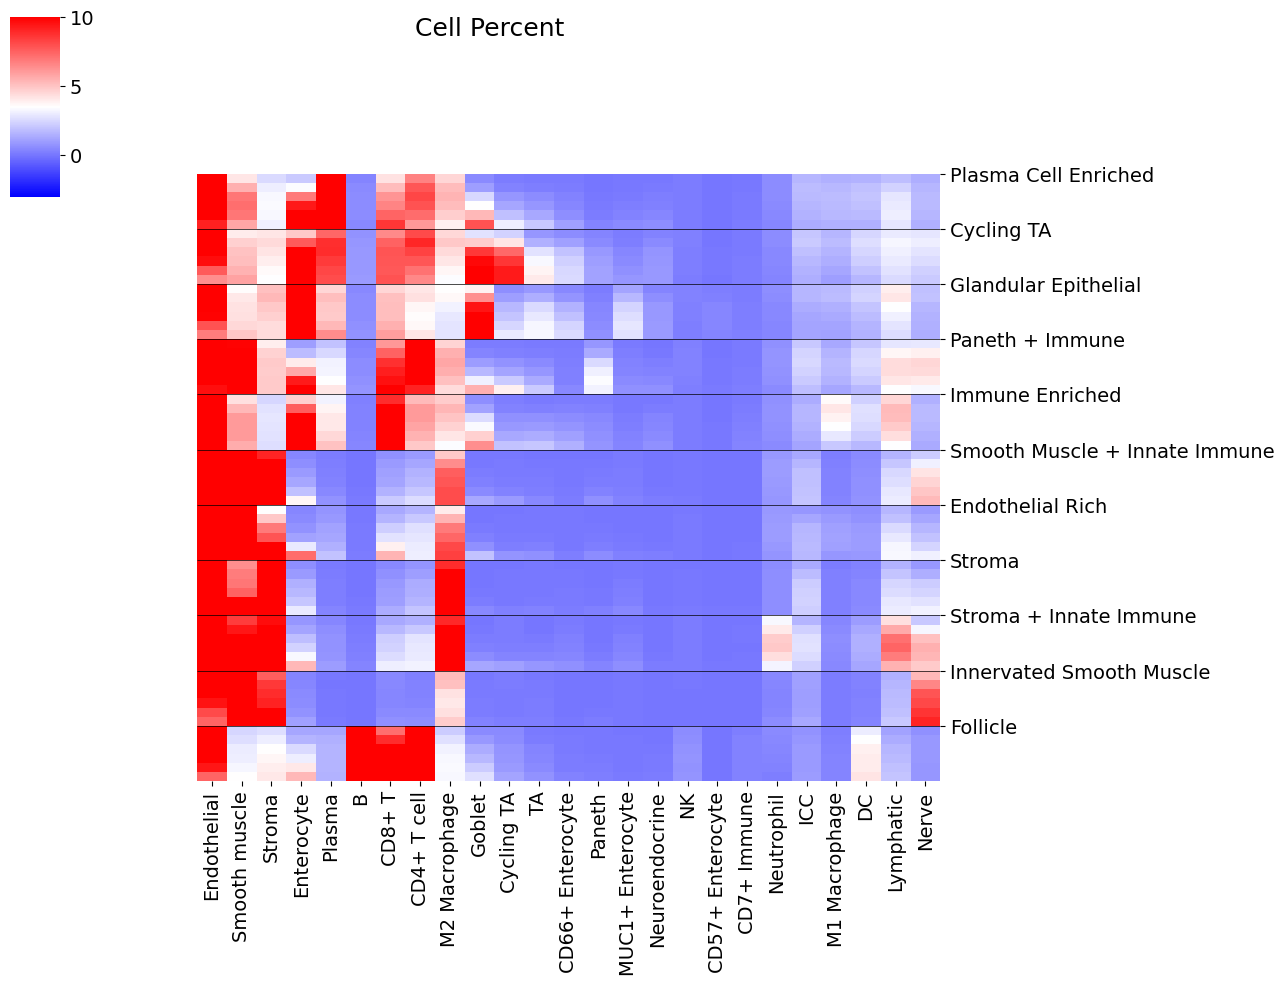

In [32]:
# looking at cell percentage as compared to total number of cells across all tissues
s=sns.clustermap(niche_comb, vmin=-3,vmax=10, cmap = 'bwr', figsize=(10,10), row_cluster=False)
s.ax_row_dendrogram.set_visible(False)
s.ax_col_dendrogram.set_visible(False)
s.fig.suptitle('Cell Percent')

heatmap_ax = s.ax_heatmap
heatmap_ax.set_yticks(np.arange(0, niche_comb.shape[0] , 6))  # Set tick positions
heatmap_ax.hlines(np.arange(6, len(niche_comb), 6), *heatmap_ax.get_xlim(),color="black", linestyle="-", linewidth=0.5)
heatmap_ax.set_yticklabels(single_nbhd_labels[::6], rotation=0)
# plt.savefig(save_path+'Endothelial_cell_percent.png', format='png', dpi=300, transparent=True, bbox_inches='tight')

In [34]:
cell_map = {
    'NK': 'blue',
 'Enterocyte': 'magenta',
 'MUC1+ Enterocyte': 'yellow',
 'TA': 'skyblue',
 'CD66+ Enterocyte': 'darkorange',
 'Paneth': 'green',
 'Smooth muscle': 'red',
 'Cycling TA': 'tan',
 'M1 Macrophage': 'gray',
 'Goblet': 'indigo',
 'Neuroendocrine': 'yellowgreen',
 'CD57+ Enterocyte': 'lightsalmon',
 'Lymphatic': 'plum',
 'CD8+ T': 'gold',
 'DC': 'blueviolet',
 'M2 Macrophage': 'bisque',
 'B': 'navy',
 'Neutrophil': 'goldenrod',
 'Endothelial': 'black',
 'Plasma': 'yellow',
 'CD4+ T cell': 'brown',
 'Stroma': 'dimgray',
 'Nerve': 'olive',
 'ICC': 'teal',
 'CD7+ Immune': 'lightcoral'}

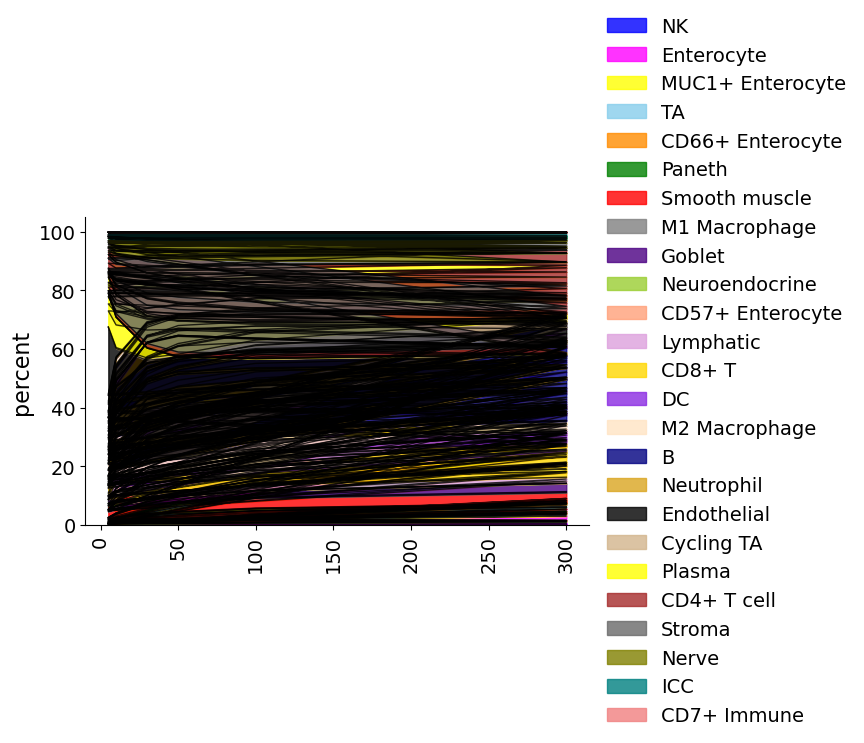

In [35]:
#first subplot
ax1 = niche_comb.plot.area(alpha = 0.8, linewidth=1, color=[cell_map.get(x) for x in niche_comb.columns],\
                           figsize =(6.5,4), rot=90)
for line in ax1.lines:
    line.set_color('black')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_ylabel('percent')

lgd2 = ax1.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1, frameon=False)

#plt.savefig(save_path+'Panethcell_areaplot.png', format='png', dpi=300, transparent=True, bbox_inches='tight')

#### Neighborhood Focused

In [ ]:
#Choose this information and input based on above
ks = [5,10,30,50,100,300] # k=5 means it collects 5 nearest neighbors for each center cell
path_to_data = '/Users/jodie/OneDrive/Documents/Duke/Hickey Lab/23_09_CODEX_HuBMAP_alldata_Dryad_merged.csv'

X = 'x'
Y = 'y'
reg = 'unique_region'
cluster_col = 'Neighborhood'

# cellhier_path = '/content/drive/MyDrive/panorgan/cellhier'
# keep_cols = [X,Y,reg,cluster_col,'Cell Type']
# save_path = '/content/drive/MyDrive/panorgan'

In [ ]:
# ! git clone https://github.com/HickeyLab/Hierarchical-Tissue-Unit-Annotation.git

In [ ]:
#Import Neighborhood Functions and Code
cellhier_path = 'Hierarchical-Tissue-Unit-Annotation/'
sys.path.append(cellhier_path)
from cellhier.general import *
from cellhier.plot_john import *
from cellhier.knn_graph_neighborhood2 import *  # Imports everything

keep_cols = [X,Y,reg,cluster_col,'Cell Type']

In [ ]:
#Import Data
n_neighbors = max(ks)
# sys.path.append(cellhier_path)
# from cellhier.general import *

cells = pd.read_csv(path_to_data)
cells = pd.concat([cells,pd.get_dummies(cells[cluster_col], dtype=int)],axis=1)
sum_cols = cells[cluster_col].unique()
values = cells[sum_cols].values

In [ ]:
#Get each region
tissue_group = cells[[X,Y,reg]].groupby(reg)
exps = list(cells[reg].unique())
tissue_chunks = [(time.time(),exps.index(t),t,a) for t,indices in tissue_group.groups.items() for a in np.array_split(indices,1)]
tissues = [get_windows(job,n_neighbors) for job in tissue_chunks]

In [ ]:
#Loop over k to compute neighborhoods
out_dict = {}
for k in ks:
    for neighbors,job in zip(tissues,tissue_chunks):

        chunk = np.arange(len(neighbors))#indices
        tissue_name = job[2]
        indices = job[3]
        window = values[neighbors[chunk,:k].flatten()].reshape(len(chunk),k,len(sum_cols)).sum(axis = 1)
        out_dict[(tissue_name,k)] = (window.astype(np.float16),indices)

windows = {}
for k in ks:

    window = pd.concat([pd.DataFrame(out_dict[(exp,k)][0],index = out_dict[(exp,k)][1].astype(int),columns = sum_cols) for exp in exps],axis=0)
    window = window.loc[cells.index.values]
    window = pd.concat([cells[keep_cols],window],axis=1)
    windows[k] = window

In [ ]:
os.environ['OMP_NUM_THREADS'] = '4' # For running on Windows with MKL

#Fill in based on above
k = 50
n_neighborhoods = 1
neighborhood_name = "neighborhood"+str(k)
k_centroids = {}

#choose windows with k calculated of interest
windows2 = windows[k]
windows2[cluster_col] = cells[cluster_col]

#Only use T cell windows for example in cell_list
cell_name = 'endothelial cells'
#cell_list = ['Paneth','OLFM4+ Enterocyte']
cell_list = ['Endothelial']
celltype_windows = windows2[windows2['Cell Type'].isin(cell_list)]
type_cells = cells[cells['Cell Type'].isin(cell_list)]

#Add lables
km = MiniBatchKMeans(n_clusters = n_neighborhoods,random_state=0)

labels = km.fit_predict(celltype_windows[sum_cols].values)
k_centroids[k] = km.cluster_centers_
type_cells[neighborhood_name] = labels

#Get out heat
k_to_plot = k
niche_clusters = (k_centroids[k_to_plot])
tissue_avgs = values.mean(axis = 0)
fc = np.log2(((niche_clusters+tissue_avgs)/(niche_clusters+tissue_avgs).sum(axis = 1, keepdims = True))/tissue_avgs)
fc = pd.DataFrame(fc,columns = sum_cols)
fc_output = fc.rename(index={0:k})
fc_output

In [ ]:
def fc_out(data, k_num):
    #Fill in based on above
    k = k_num
    n_neighborhoods = 1
    neighborhood_name = "neighborhood"+str(k)
    k_centroids = {}

    #choose windows with k calculated of interest
    windows2 = windows[k]
    windows2[cluster_col] = data[cluster_col]

    #Only use T cell windows for example in cell_list
    cell_name = 'endothelial data'
    #cell_list = ['Paneth','OLFM4+ Enterocyte']
    cell_list = ['Endothelial']
    celltype_windows = windows2[windows2['Cell Type'].isin(cell_list)]
    type_data = data[data['Cell Type'].isin(cell_list)]

    #Add lables
    km = MiniBatchKMeans(n_clusters = n_neighborhoods,random_state=0)

    labels = km.fit_predict(celltype_windows[sum_cols].values)
    k_centroids[k] = km.cluster_centers_
    type_data[neighborhood_name] = labels

    #Get out heat
    k_to_plot = k
    niche_clusters = (k_centroids[k_to_plot])
    tissue_avgs = values.mean(axis = 0)
    fc = np.log2(((niche_clusters+tissue_avgs)/(niche_clusters+tissue_avgs).sum(axis = 1, keepdims = True))/tissue_avgs)
    fc = pd.DataFrame(fc,columns = sum_cols)
    niche_aveg = pd.DataFrame(niche_clusters,columns = sum_cols)
    niche_avegg = niche_aveg/niche_aveg.sum(axis=1)[0]*100

    fc_output = fc.rename(index={0:k})
    niche_out = niche_avegg.rename(index={0:k})
    return fc_output, niche_out

In [ ]:
fc_list = []
niche_list = []
for kn in ks:
    df1, df2 = fc_out(data=cells, k_num=kn)
    fc_list.append(df1)
    niche_list.append(df2)

fc_comb = pd.concat(fc_list)
niche_comb=pd.concat(niche_list)
niche_comb

In [ ]:
s=sns.clustermap(fc_comb, vmin =-3,vmax = 3,cmap = 'bwr', figsize=(9,6),cbar_pos=(0.01,0.07,0.03,0.1))

s.ax_row_dendrogram.set_visible(False)
s.ax_col_dendrogram.set_visible(False)
#s.ax_heatmap.set_ylabel("", labelpad=25)
#s.ax_heatmap.tick_params(axis='y', pad=15)
#s.ax_heatmap.yaxis.set_ticks_position("left")

#plt.savefig(save_path+'EndothelialCell_enrichment_neigh.png', format='png', dpi=300, transparent=True, bbox_inches='tight')

In [ ]:
s=sns.clustermap(niche_comb, vmax=10, cmap = 'bwr', figsize=(9,6), row_cluster=False)
s.ax_row_dendrogram.set_visible(False)
s.ax_col_dendrogram.set_visible(False)
#plt.savefig(save_path+'Panethcell_percent_neigh.png', format='png', dpi=300, transparent=True, bbox_inches='tight')

In [ ]:
neigh_map = {
 'Transit Amplifying Zone': 'darkblue',
 'Microvasculature': 'black',
 'Adatpive Immune Enriched': 'orange',
 'Glandular Epithelial': 'darkorange',
 'CD66+ Mature Epithelial': 'firebrick',
 'Stroma & Innate Immune': 'brown',
 'CD8+ T Enriched IEL': 'green',
 'Mature Epithelial': 'magenta',
 'Innate Immune Enriched': 'skyblue',
 'Outer Follicle': 'navy',
 'Plasma Cell Enriched': 'yellow',
 'Innervated Stroma': 'blueviolet',
 'Stroma': 'gray',
 'Macrovasculature': 'gold',
 'Secretory Epithelial': 'yellowgreen',
 'Smooth Muscle': 'red',
 'Innervated Smooth Muscle': 'lightgreen',
 'Inner Follicle': 'blue',
 'Smooth Muscle & Innate Immune': 'tan',
 'Paneth Enriched': 'lightblue'}

In [ ]:
#first subplot
ax1 = niche_comb.plot.area(alpha = 0.8, linewidth=1, color=[neigh_map.get(x) for x in niche_comb.columns],figsize =(6.5,4), rot=90)
# ax1 = niche_comb.plot.area(alpha = 0.8, linewidth=1, figsize =(6.5,4), rot=90)
for line in ax1.lines:
    line.set_color('black')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_ylabel('percent')

lgd2 = ax1.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1, frameon=False)

#plt.savefig(save_path+'Endothelialcell_areaplot_neigh.png', format='png', dpi=300, transparent=True, bbox_inches='tight')

In [ ]:
#Check to make sure that correct values were obtained
celltype_windows[cluster_col].value_counts()

In [ ]:
os.environ['OMP_NUM_THREADS'] = '4' # For running on Windows with MKL
km = MiniBatchKMeans(n_clusters = n_neighborhoods,random_state=0)

labels = km.fit_predict(celltype_windows[sum_cols].values)
k_centroids[k] = km.cluster_centers_
type_cells[neighborhood_name] = labels

In [ ]:
windows2

In [ ]:
#this plot shows the types of cells (ClusterIDs) in the different niches (0-9)
k_to_plot = k
niche_clusters = (k_centroids[k_to_plot])
tissue_avgs = values.mean(axis = 0)
fc = np.log2(((niche_clusters+tissue_avgs)/(niche_clusters+tissue_avgs).sum(axis = 1, keepdims = True))/tissue_avgs)
fc = pd.DataFrame(fc,columns = sum_cols)
s=sns.clustermap(fc_comb, vmin =-3,vmax = 3,cmap = 'bwr',square=True,cbar=True,figsize=(8,5))
#s.savefig(save_path+"celltypes_perniche_"+"_"+str(k)+".png", dpi=600)


#### UMAP visualization - neighborhoods

In [ ]:
import scanpy as sc

##### Format data

In [ ]:
type_cells['neigh_str'] = type_cells['neighborhood'+str(k)].astype(str)
type_cells.columns

In [ ]:
markerlist = [
    'tissue', 'donor', 'region', 'Xcorr', 'Ycorr',
    'Tissue_location', 'array', 'Cell Type', 'Cell Type em','Cell subtype',
    'Neighborhood', 'Neighborhood_Ind', 'Neigh_sub',
    'NeighInd_sub', 'Community', 'Major Community', 'Tissue Segment']

#Add in markers for potential clustering later
markerlist.append('neighborhood'+str(k))

marker_df = type_cells[markerlist]


#turn into dictionary so I can extract values later for dataframe
tfc = fc.T
#key 1 is neighborhood number, #key 2 is the cell type
dict_tfc = tfc.to_dict()
#Map back with neighborhood number
for cell_type_unique in dict_tfc[0].keys():
    marker_df[str('Enriched ')+cell_type_unique] = marker_df['neighborhood'+str(k)].apply(lambda x:dict_tfc[x][cell_type_unique])

marker_df['Community'].unique()

In [ ]:
comb_df = pd.concat([celltype_windows, marker_df], axis=1)
comb_df

In [ ]:
#Read in Data and Rename ClusterID with Named Values
df = comb_df.copy()
#make neighborhood not an integer
df['neighborhood'+str(k)] = df['neighborhood'+str(k)].astype(str)
df['neighborhood'+str(k)]

In [ ]:
cell_enr = [
    'Enriched Mature Epithelial', 'Enriched Transit Amplifying Zone',
       'Enriched Innate Immune Enriched', 'Enriched Stroma & Innate Immune',
       'Enriched Outer Follicle', 'Enriched Adatpive Immune Enriched',
       'Enriched Secretory Epithelial', 'Enriched CD66+ Mature Epithelial',
       'Enriched Plasma Cell Enriched', 'Enriched Innervated Stroma',
       'Enriched Smooth Muscle & Innate Immune', 'Enriched Microvasculature',
       'Enriched Innervated Smooth Muscle', 'Enriched Inner Follicle',
       'Enriched Macrovasculature', 'Enriched Stroma',
       'Enriched Glandular Epithelial', 'Enriched CD8+ T Enriched IEL',
       'Enriched Smooth Muscle', 'Enriched Paneth Enriched'
]
collist = [
       'x', 'y', 'unique_region', 'tissue',
       'donor', 'region', 'Xcorr', 'Ycorr', 'Tissue_location', 'array', 'Cell Type',
       'Cell subtype', 'Neighborhood', 'Neighborhood_Ind',
       'Neigh_sub', 'NeighInd_sub', 'Community', 'Major Community','Tissue Segment'
 ]
#Prepare for making into anndata format so that obs and data are separate
windows_list = [
       'Mature Epithelial', 'Transit Amplifying Zone',
       'Innate Immune Enriched', 'Stroma & Innate Immune', 'Outer Follicle',
       'Adatpive Immune Enriched', 'Secretory Epithelial',
       'CD66+ Mature Epithelial', 'Plasma Cell Enriched', 'Innervated Stroma',
       'Smooth Muscle & Innate Immune', 'Microvasculature',
       'Innervated Smooth Muscle', 'Inner Follicle', 'Macrovasculature',
       'Stroma', 'Glandular Epithelial', 'CD8+ T Enriched IEL',
       'Smooth Muscle', 'Paneth Enriched',]

In [ ]:
df1 = df.drop(columns = collist) #USER INPUT
df1.columns

In [ ]:
#Prepare for making into anndata format
dfw = df[windows_list]
dfw.columns

In [ ]:
#Convert to anndata format
adata_w = sc.AnnData(dfw)
collist.extend(cell_enr)

adata_w.obs = df[collist]
adata_w


##### Leiden clustering in replacement of K means

In [ ]:
sc.settings.figdir='single_cell_neighborhood'
sc.settings.set_figure_params(dpi=80, facecolor='white',dpi_save=300, transparent=True, frameon=False, fontsize=22)
plt.rcParams["legend.markerscale"] = 1



In [ ]:
print(adata_w.obs['Community'].unique())
print(adata_w.obs.columns)
print(adata_w.obs)

In [ ]:
sc.pp.neighbors(adata_w, n_neighbors=20)
sc.tl.umap(adata_w)
sc.pl.umap(adata_w, color ='Community',)

In [ ]:
sc.pl.umap(adata_w, color ='Tissue_location',)